In [1]:
#LOAD DATA AND PREPROCESSING
import pandas as pd
import numpy as np
import ast

# === STEP 1: LOAD & RENAME ===
data_path = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/20251023-s288c-annotated-PPI-net.pkl"
df = pd.read_pickle(data_path)

# === STEP 2: SUBSET AND CLEAN ===
selected_columns = df[[
    'node', '_wkshell', 'Y2H_wkshell',
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality', 'closeness_centrality',
    'load_centrality', 'pagerank', 'information_centrality',
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality',
    'DeepTMHMM_class', 'signalP_trimmed_sequence',
    'IDR_count', 'N_aa_disordered', 'disorder_fraction',
    'is_disordered_0.05', 'is_disordered_0.10', 'is_disordered_0.15', 'is_disordered_0.20', 'is_disordered_0.25', 'is_disordered_0.30', 'is_disordered_0.35', 
    'is_disordered_0.40', 'is_disordered_0.45', 'is_disordered_0.50', 'is_disordered_0.55', 'is_disordered_0.60', 'is_disordered_0.65', 'is_disordered_0.70', 
    'is_disordered_0.75', 'is_disordered_0.80', 'is_disordered_0.85', 'is_disordered_0.90', 'is_disordered_0.95', 'is_disordered_1.00',
    'mean_plddt', 'L', 
    'Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score', 'FoldX_best_total_energy',
    'Christiano_degradation_rate(min-1)', 'Villen_halflife_min',
    'mean_molecules_per_cell', 'median_molecules_per_cell', 'log2_TE',
    'interacting_chaperones', 'in_complex', 'Pfam_Ndomains', 
    'essential',  
    'sequence', 'structure_exists', 'sequence_matches_structure', 'meltome-melting-point'
       
]].copy()

# Multiply 'cagiada-dG' by -1 (flip sign)
selected_columns['cagiada-dG'] = pd.to_numeric(selected_columns['cagiada-dG'], errors='coerce') * -1

# Replace infinite values with NaN to allow proper cleaning
selected_columns.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fix Pfam_Ndomains: replace empty/NaN with 0
selected_columns['Pfam_Ndomains'] = selected_columns['Pfam_Ndomains'].fillna(0).astype(int)

# === STEP 3: DERIVED FEATURES ===
selected_columns['Length'] = selected_columns['signalP_trimmed_sequence'].fillna('').apply(len)

# Add percentile columns for all centrality metrics
ms_centrality_cols = [
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality',
    'closeness_centrality', 'load_centrality', 'pagerank', 'information_centrality'
]
y2h_centrality_cols = [
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality'
]

# Rename MS columns
ms_rename_map = {col: "MS_" + col for col in ms_centrality_cols}
selected_columns.rename(columns=ms_rename_map, inplace=True)

# Add percentiles for MS-based metrics
for col in ms_centrality_cols:
    ms_col = "MS_" + col
    selected_columns[f"{ms_col}_percentile"] = selected_columns[ms_col].rank(pct=True) * 100

# Add percentiles for Y2H-based metrics
for col in y2h_centrality_cols:
    selected_columns[f"{col}_percentile"] = selected_columns[col].rank(pct=True) * 100

# === STEP 4: ONE HOT ENCODING FOR CHAPERONES ===
def fix_list(val):
    if isinstance(val, list):
        return val
    elif isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    elif pd.isnull(val):
        return []
    else:
        return []

selected_columns['interacting_chaperones'] = selected_columns['interacting_chaperones'].apply(fix_list)

def chaperone_category(row):
    node = row['node']
    chaps = row['interacting_chaperones']
    if not chaps or chaps == []:
        return 'protein_is_neither_chaperone_nor_interacts'
    elif node in chaps:
        return 'protein_is_chaperone'
    else:
        return 'protein_interacts_with_chaperone'

selected_columns['chaperone_category'] = selected_columns.apply(chaperone_category, axis=1)
selected_columns['is_chaperone'] = (selected_columns['chaperone_category'] == 'protein_is_chaperone').astype(int)
selected_columns['interacts_with_chaperone'] = (selected_columns['chaperone_category'] == 'protein_interacts_with_chaperone').astype(int)
selected_columns['neither_chaperone_nor_interacts'] = (selected_columns['chaperone_category'] == 'protein_is_neither_chpaerone_nor_interacts').astype(int)

# === STEP 5: Match seq and structure nodes ===
selected_columns.info()
selected_columns = selected_columns[~selected_columns["sequence"].isna()]
print (f"Number of nodes with sequence information: {selected_columns.shape[0]}")

# record those nodes that do not have sequence information
no_seq_nodes = selected_columns[selected_columns["sequence"].isna()]
print (f"Number of nodes without sequence information: {no_seq_nodes.shape[0]}")

# remove nodes with no structure from AF2
selected_columns = selected_columns[selected_columns["structure_exists"] == 1]
print (f"Number of nodes with sequence & structure information: {selected_columns.shape[0]}")

# a small number of nodes have an AF2 structure, but its sequence does not match the sequence information from SGD - we can filter those out as well
selected_columns = selected_columns[selected_columns["sequence_matches_structure"] == True]
print (f"Number of nodes with sequence, structure, and matching information between the two: {selected_columns.shape[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3927 entries, 0 to 3926
Data columns (total 80 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   node                                   3927 non-null   object 
 1   _wkshell                               3927 non-null   int64  
 2   Y2H_wkshell                            1465 non-null   float64
 3   MS_degree_centrality                   3927 non-null   float64
 4   MS_betweenness_centrality              3927 non-null   float64
 5   MS_eigenvector_centrality              3927 non-null   float64
 6   MS_closeness_centrality                3927 non-null   float64
 7   MS_load_centrality                     3927 non-null   float64
 8   MS_pagerank                            3927 non-null   float64
 9   MS_information_centrality              3927 non-null   float64
 10  Y2H_degree_centrality                  1465 non-null   float64
 11  Y2H_

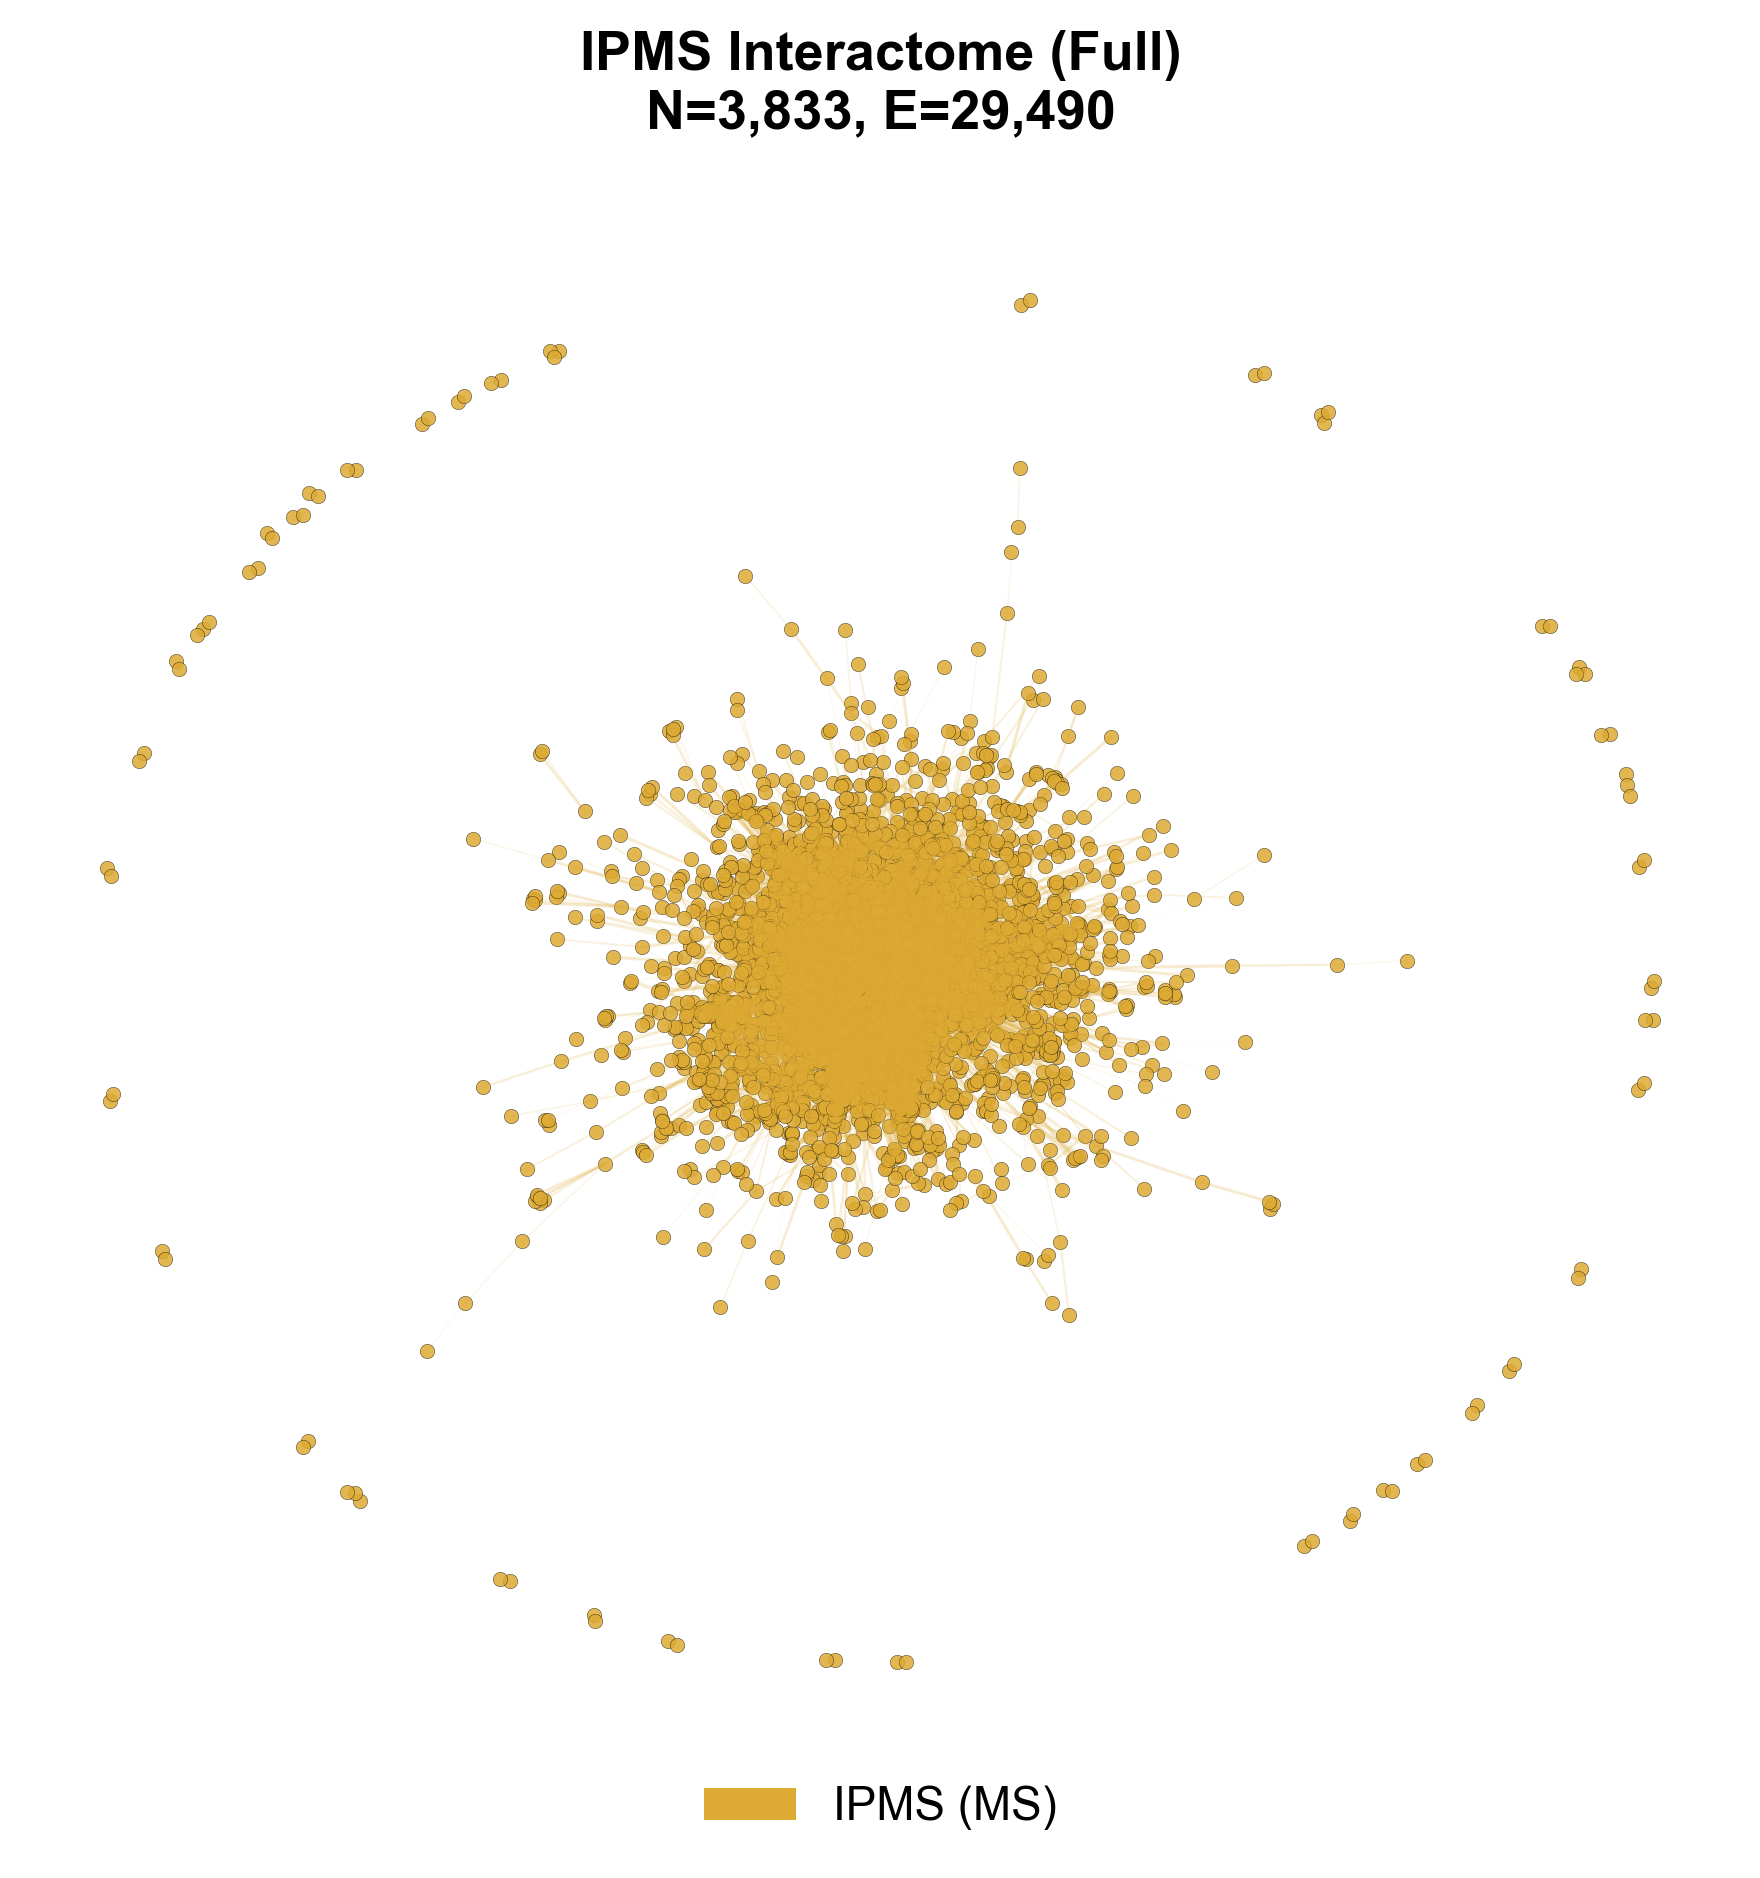

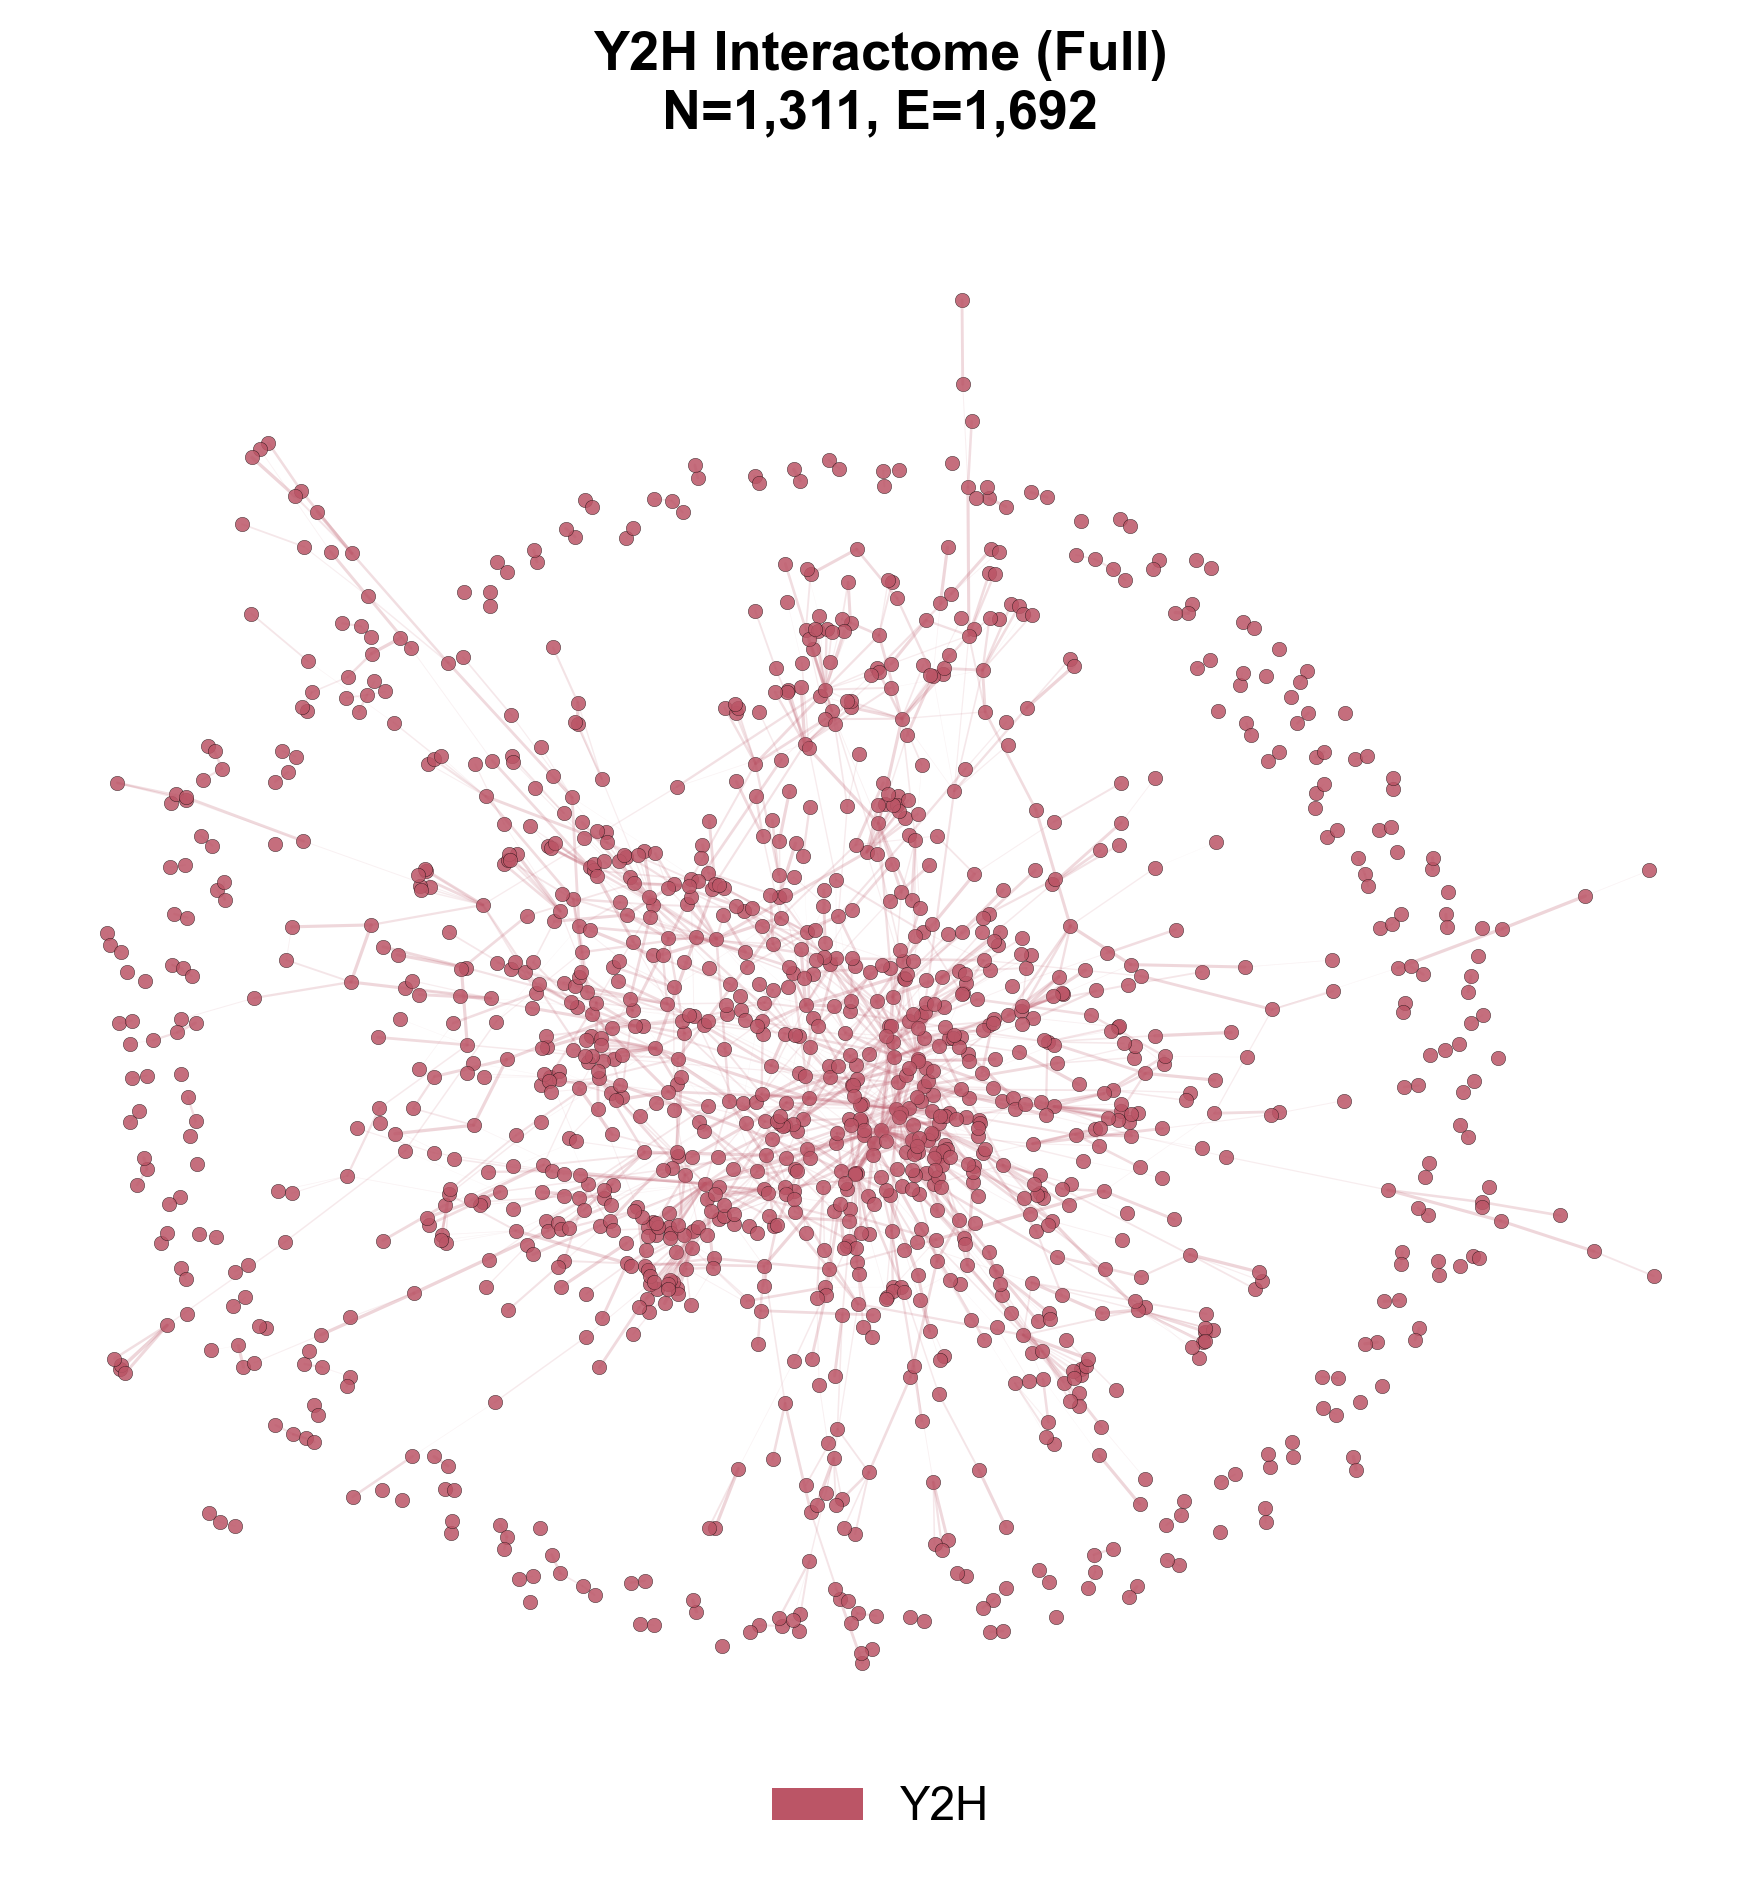

MS LCC: 3,747 nodes, 29,442 edges
Y2H LCC: 1,011 nodes, 1,496 edges


In [65]:
#PLOT FULL INTERACTION NETWORKS
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# =========================================
# 0. GLOBAL VISUAL SETTINGS
# =========================================
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

# =========================================
# 1. FILTERED INTERACTOMES
# =========================================
valid_nodes = set(selected_columns['node'])

# --- MS Interactome ---
df_ms_filtered = df_ms[df_ms['source'].isin(valid_nodes) & df_ms['target'].isin(valid_nodes)]
G_ms = nx.from_pandas_edgelist(df_ms_filtered, 'source', 'target')
ms_nodes_full, ms_edges_full = G_ms.number_of_nodes(), G_ms.number_of_edges()

# --- Y2H Interactome ---
filtered_y2h_edges = [(s, t) for s, t in zip(sources, targets) if s in valid_nodes and t in valid_nodes]
G_y2h = nx.Graph()
G_y2h.add_edges_from(filtered_y2h_edges)
y2h_nodes_full, y2h_edges_full = G_y2h.number_of_nodes(), G_y2h.number_of_edges()


# =========================================
# 2. FUNCTION FOR HIGH-QUALITY DRAWING
# =========================================
def plot_high_quality_network(G, title, color, save_name, legend_label, node_size=12):
    """Draws a high-quality dense network with visual depth and smooth rendering."""
    fig, ax = plt.subplots(figsize=(6, 6))

    # --- Stable, visually balanced layout ---
    pos = nx.spring_layout(G, seed=42, k=0.12, iterations=100)

    # --- Compute edge layering (depth effect): darker for background, lighter for front ---
    edges = np.array(list(G.edges()))
    np.random.shuffle(edges)  # randomize order for organic layering
    n_edges = len(edges)
    alphas = np.linspace(0.05, 0.25, n_edges)  # gradual transparency
    widths = np.linspace(0.1, 0.8, n_edges)    # variable edge width

    # --- Draw edges with gradual depth ---
    for (i, (u, v)) in enumerate(edges):
        ax.plot(
            [pos[u][0], pos[v][0]],
            [pos[u][1], pos[v][1]],
            color=color,
            lw=widths[i],
            alpha=alphas[i],
            solid_capstyle='round',
            zorder=i
        )

    # --- Draw nodes with subtle halo effect ---
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_size,
        node_color=color,
        alpha=0.85,
        linewidths=0.1,
        edgecolors='black'
    )

    # --- Title & Legend ---
    ax.set_title(title, fontsize=13, fontweight='semibold')
    ax.axis('off')
    legend_elements = [Patch(facecolor=color, label=legend_label, edgecolor='none')]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=1, frameon=False)

    # --- Tight layout & save ---
    plt.tight_layout()
    plt.savefig(save_name, bbox_inches='tight', facecolor='white')
    plt.show()


# =========================================
# 3. DRAW FULL INTERACTOMES
# =========================================
plot_high_quality_network(
    G_ms,
    title=f"IPMS Interactome (Full)\nN={ms_nodes_full:,}, E={ms_edges_full:,}",
    color="#DDAA33",
    save_name="/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE1/1A-ms_full_interactome.svg",
    legend_label="IPMS (MS)"
)

plot_high_quality_network(
    G_y2h,
    title=f"Y2H Interactome (Full)\nN={y2h_nodes_full:,}, E={y2h_edges_full:,}",
    color="#BB5566",
    save_name="/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE1/1A-y2h_full_interactome.svg",
    legend_label="Y2H"
)


# =========================================
# 4. LARGEST CONNECTED COMPONENTS (LCC)
# =========================================
#largest_cc_ms = max(nx.connected_components(G_ms), key=len)
#G_ms_lcc = G_ms.subgraph(largest_cc_ms).copy()
#ms_nodes_lcc, ms_edges_lcc = G_ms_lcc.number_of_nodes(), G_ms_lcc.number_of_edges()

#largest_cc_y2h = max(nx.connected_components(G_y2h), key=len)
#G_y2h_lcc = G_y2h.subgraph(largest_cc_y2h).copy()
#y2h_nodes_lcc, y2h_edges_lcc = G_y2h_lcc.number_of_nodes(), G_y2h_lcc.number_of_edges()

#plot_high_quality_network(
#    G_ms_lcc,
#    title=f"IPMS Interactome (LCC)\nN={ms_nodes_lcc:,}, E={ms_edges_lcc:,}",
#    color="#DDAA33",
#    save_name="/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE1/1A-ms_lcc_comparison.svg",
#    legend_label="IPMS (MS)"
#)

#plot_high_quality_network(
#    G_y2h_lcc,
#    title=f"Y2H Interactome (LCC)\nN={y2h_nodes_lcc:,}, E={y2h_edges_lcc:,}",
#    color="#BB5566",
#    save_name="/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE1/1A-y2h_lcc_comparison.svg",
#    legend_label="Y2H"
#)

# =========================================
# 5. PRINT STATS
# =========================================
print(f"MS LCC: {ms_nodes_lcc:,} nodes, {ms_edges_lcc:,} edges")
print(f"Y2H LCC: {y2h_nodes_lcc:,} nodes, {y2h_edges_lcc:,} edges")

In [58]:
#COMPUTE NUMBER OF NODE & EDGE 
# Set of valid filtered nodes from your EDA dataframe
valid_nodes = set(selected_columns['node'])

# Filtered MS nodes and edges
nodes_ms = set(df_ms['source']).union(df_ms['target'])
nodes_ms_filtered = nodes_ms.intersection(valid_nodes)

edges_ms = set(tuple(sorted([s, t])) for s, t in zip(df_ms['source'], df_ms['target']))
edges_ms_filtered = {e for e in edges_ms if e[0] in valid_nodes and e[1] in valid_nodes}

# Filtered Y2H nodes and edges
nodes_y2h = set(sources).union(targets)
nodes_y2h_filtered = nodes_y2h.intersection(valid_nodes)

edges_y2h = set(tuple(sorted([s, t])) for s, t in zip(sources, targets))
edges_y2h_filtered = {e for e in edges_y2h if e[0] in valid_nodes and e[1] in valid_nodes}

# --- Compute intersections ---
common_nodes = nodes_ms_filtered & nodes_y2h_filtered
common_edges = edges_ms_filtered & edges_y2h_filtered

print("========== NODE & EDGE STATISTICS ==========")
print(f"Number of nodes in MS (filtered): {len(nodes_ms_filtered)}")
print(f"Number of nodes in Y2H (filtered): {len(nodes_y2h_filtered)}")
print(f"Number of nodes common in both (filtered): {len(common_nodes)}\n")

print(f"Number of edges in MS (filtered): {len(edges_ms_filtered)}")
print(f"Number of edges in Y2H (filtered): {len(edges_y2h_filtered)}")
print(f"Number of edges common in both (filtered): {len(common_edges)}")

========== NODE & EDGE STATISTICS ==========
Number of nodes in MS (filtered): 3859
Number of nodes in Y2H (filtered): 1462
Number of nodes common in both (filtered): 1462

Number of edges in MS (filtered): 29490
Number of edges in Y2H (filtered): 1692
Number of edges common in both (filtered): 430


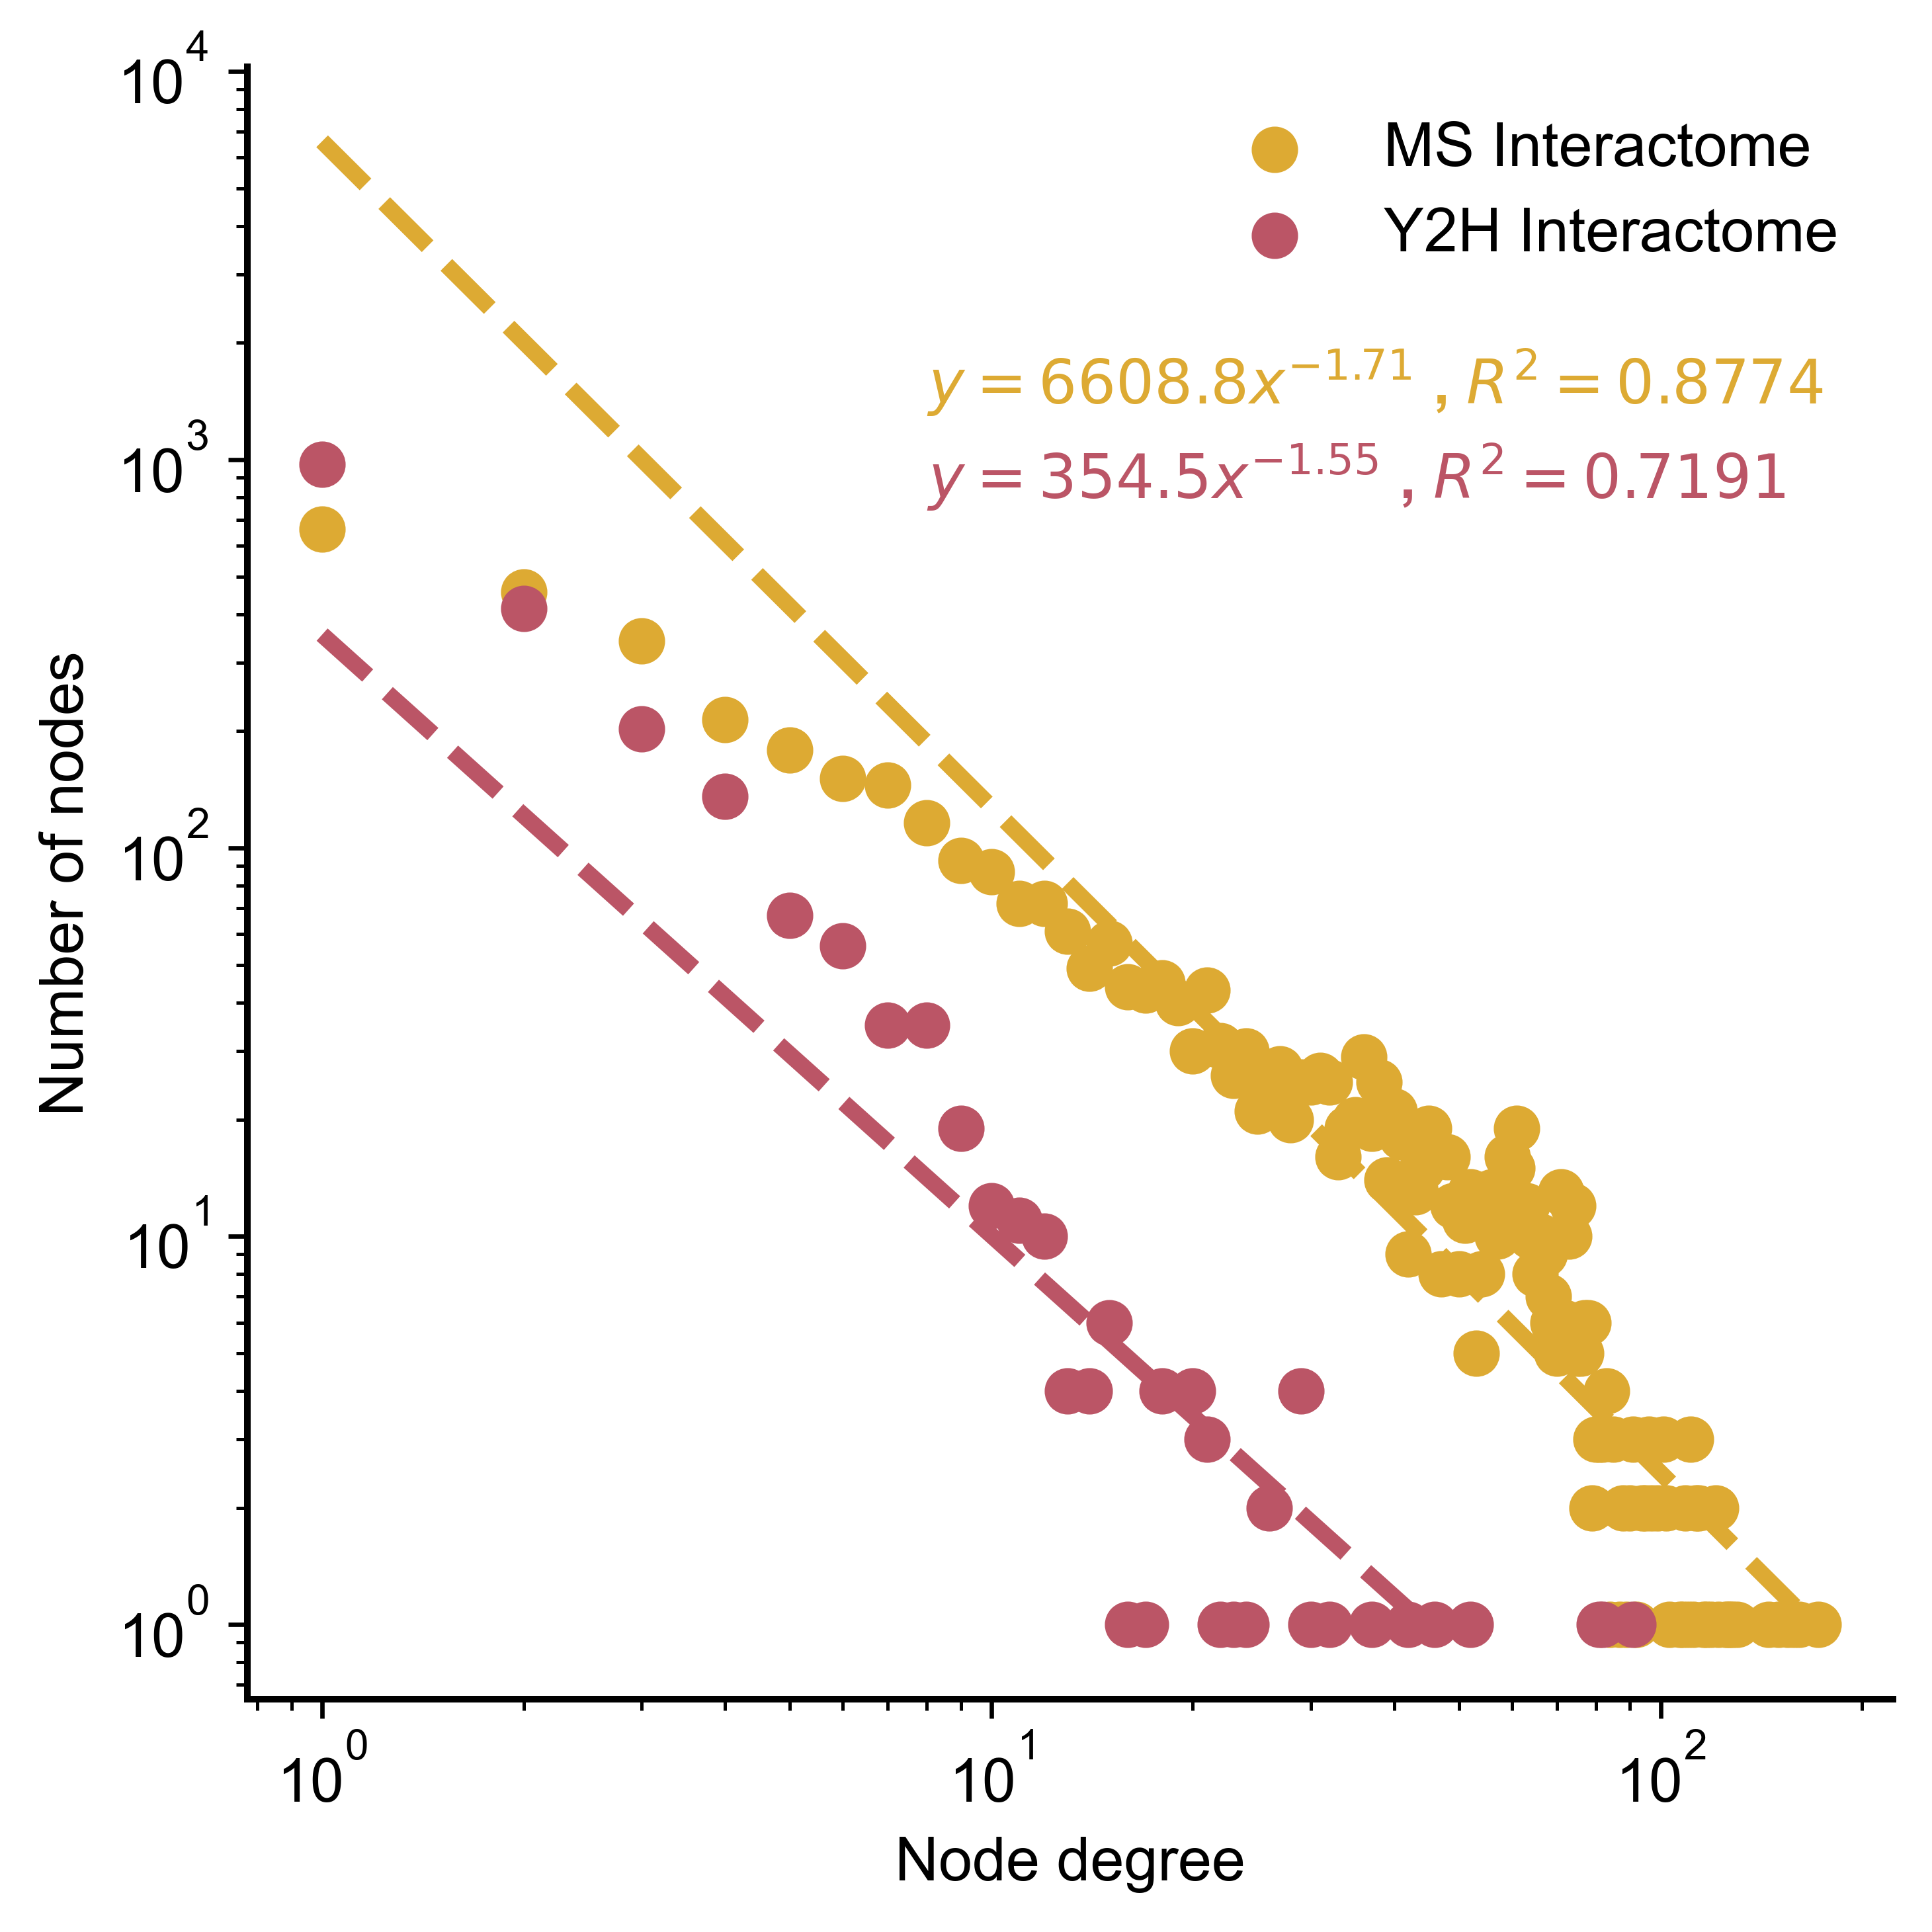

MS: slope=-1.714, intercept=3.820, R²=0.8774
Y2H: slope=-1.547, intercept=2.550, R²=0.7191


In [64]:
#PLOT DEGREE DISTRIBUTION ON A LOG-LOG SCALE USING POWER-LAW FIT (LINEAR FIT)
# =============================
# 1. Import Libraries & Set Global Aesthetics
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Publication-style font and axis settings
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# =============================
# 2. Define File Paths
# =============================
ms_edge_path = '/home/goel107/NCEMS/ANALYSIS/07_15_2025/The_Yeast_Interactome_edges.csv'
y2h_edge_path = '/home/goel107/NCEMS/ANALYSIS/07_15_2025/Y2H_union-clean_edges.csv'

# =============================
# 3. Helper Functions
# =============================
def split_interaction(s):
    parts = s.split(' (interacts with) ')
    return parts[0], parts[1]

def compute_degree_distribution(source_nodes, target_nodes):
    all_nodes = pd.concat([pd.Series(source_nodes), pd.Series(target_nodes)])
    degree_counts = all_nodes.value_counts().sort_index()
    unique_degrees, counts = np.unique(degree_counts.values, return_counts=True)
    return unique_degrees, counts

def powerlaw_fit(unique_degrees, counts, fit_range=None):
    mask = (unique_degrees > 0) & (counts > 0)
    if fit_range is not None:
        mask = mask & (unique_degrees >= fit_range[0]) & (unique_degrees <= fit_range[1])
    x = unique_degrees[mask]
    y = counts[mask]
    log_x = np.log10(x)
    log_y = np.log10(y)
    slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)
    return slope, intercept, r_value**2, x

# =============================
# 4. Load and Process Data
# =============================
# --- Mass Spec ---
df_ms = pd.read_csv(ms_edge_path)
unique_degrees_ms, counts_ms = compute_degree_distribution(df_ms['source'], df_ms['target'])

# --- Y2H ---
df_y2h = pd.read_csv(y2h_edge_path)
sources, targets = zip(*df_y2h['name'].map(split_interaction))
unique_degrees_y2h, counts_y2h = compute_degree_distribution(sources, targets)

# =============================
# 5. Publication-Quality Plotting
# =============================
fig, ax = plt.subplots(figsize=(5, 5))

# --- Plot all points ---
ax.scatter(unique_degrees_ms, counts_ms, s=55, color='#DDAA33', zorder=2, label='MS Interactome')
ax.scatter(unique_degrees_y2h, counts_y2h, s=55, color='#BB5566', zorder=2, label='Y2H Interactome')

# --- Fit power law to MS (adjust fit range if needed) ---
slope_ms, intercept_ms, R2_ms, x_fit_ms = powerlaw_fit(unique_degrees_ms, counts_ms, fit_range=(5, 200))
x_start_ms = 1
x_end_ms = 10 ** (-intercept_ms / slope_ms)
x_plot_ms = np.linspace(np.log10(x_start_ms), np.log10(x_end_ms), 100)
y_plot_ms = slope_ms * x_plot_ms + intercept_ms
ax.plot(10**x_plot_ms, 10**y_plot_ms, '--', color='#DDAA33', lw=3, zorder=3)

# --- Annotate MS fit (no box) ---
eqn_str_ms = (f"$y = {10**intercept_ms:.1f} x^{{{slope_ms:.2f}}}$ , $R^2 = {R2_ms:.4f}$")
ax.annotate(eqn_str_ms, xy=(8, 1400), fontsize=11, fontfamily='Arial', color='#DDAA33', zorder=10, fontweight='bold')

# --- Fit power law to Y2H (adjust fit range if needed) ---
slope_y2h, intercept_y2h, R2_y2h, x_fit_y2h = powerlaw_fit(unique_degrees_y2h, counts_y2h, fit_range=(5, 100))
x_start_y2h = 1
x_end_y2h = 10 ** (-intercept_y2h / slope_y2h)
x_plot_y2h = np.linspace(np.log10(x_start_y2h), np.log10(x_end_y2h), 100)
y_plot_y2h = slope_y2h * x_plot_y2h + intercept_y2h
ax.plot(10**x_plot_y2h, 10**y_plot_y2h, '--', color='#BB5566', lw=3, zorder=3)

# --- Annotate Y2H fit (no box) ---
eqn_str_y2h = (f"$y = {10**intercept_y2h:.1f} x^{{{slope_y2h:.2f}}}$ , $R^2 = {R2_y2h:.4f}$")
ax.annotate(eqn_str_y2h, xy=(8, 800), fontsize=11, fontfamily='Arial', color='#BB5566', zorder=10, fontweight='bold')

# --- Axes ---
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Node degree', color='black')
ax.set_ylabel('Number of nodes', color='black')
#ax.set_title('Degree distribution', fontsize=17, loc='left', fontweight='bold')
ax.tick_params(axis='both', labelsize=11, colors='black')
ax.legend(loc='upper right', fontsize=11, frameon=False)
fig.tight_layout()

# --- Clean spines (Origin style) ---
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# --- Save and/or show ---
pd.DataFrame({'degree': unique_degrees_ms, 'count': counts_ms}).to_csv("ms_degree.csv", index=False)
pd.DataFrame({'degree': unique_degrees_y2h, 'count': counts_y2h}).to_csv("y2h_degree.csv", index=False)
fig.savefig("/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE1/1D-log-log_plot(linear-fit).svg", dpi=300, bbox_inches='tight')
plt.show()

# =============================
# 6. Output Fit Parameters (if needed)
# =============================
print(f"MS: slope={slope_ms:.3f}, intercept={intercept_ms:.3f}, R²={R2_ms:.4f}")
print(f"Y2H: slope={slope_y2h:.3f}, intercept={intercept_y2h:.3f}, R²={R2_y2h:.4f}")

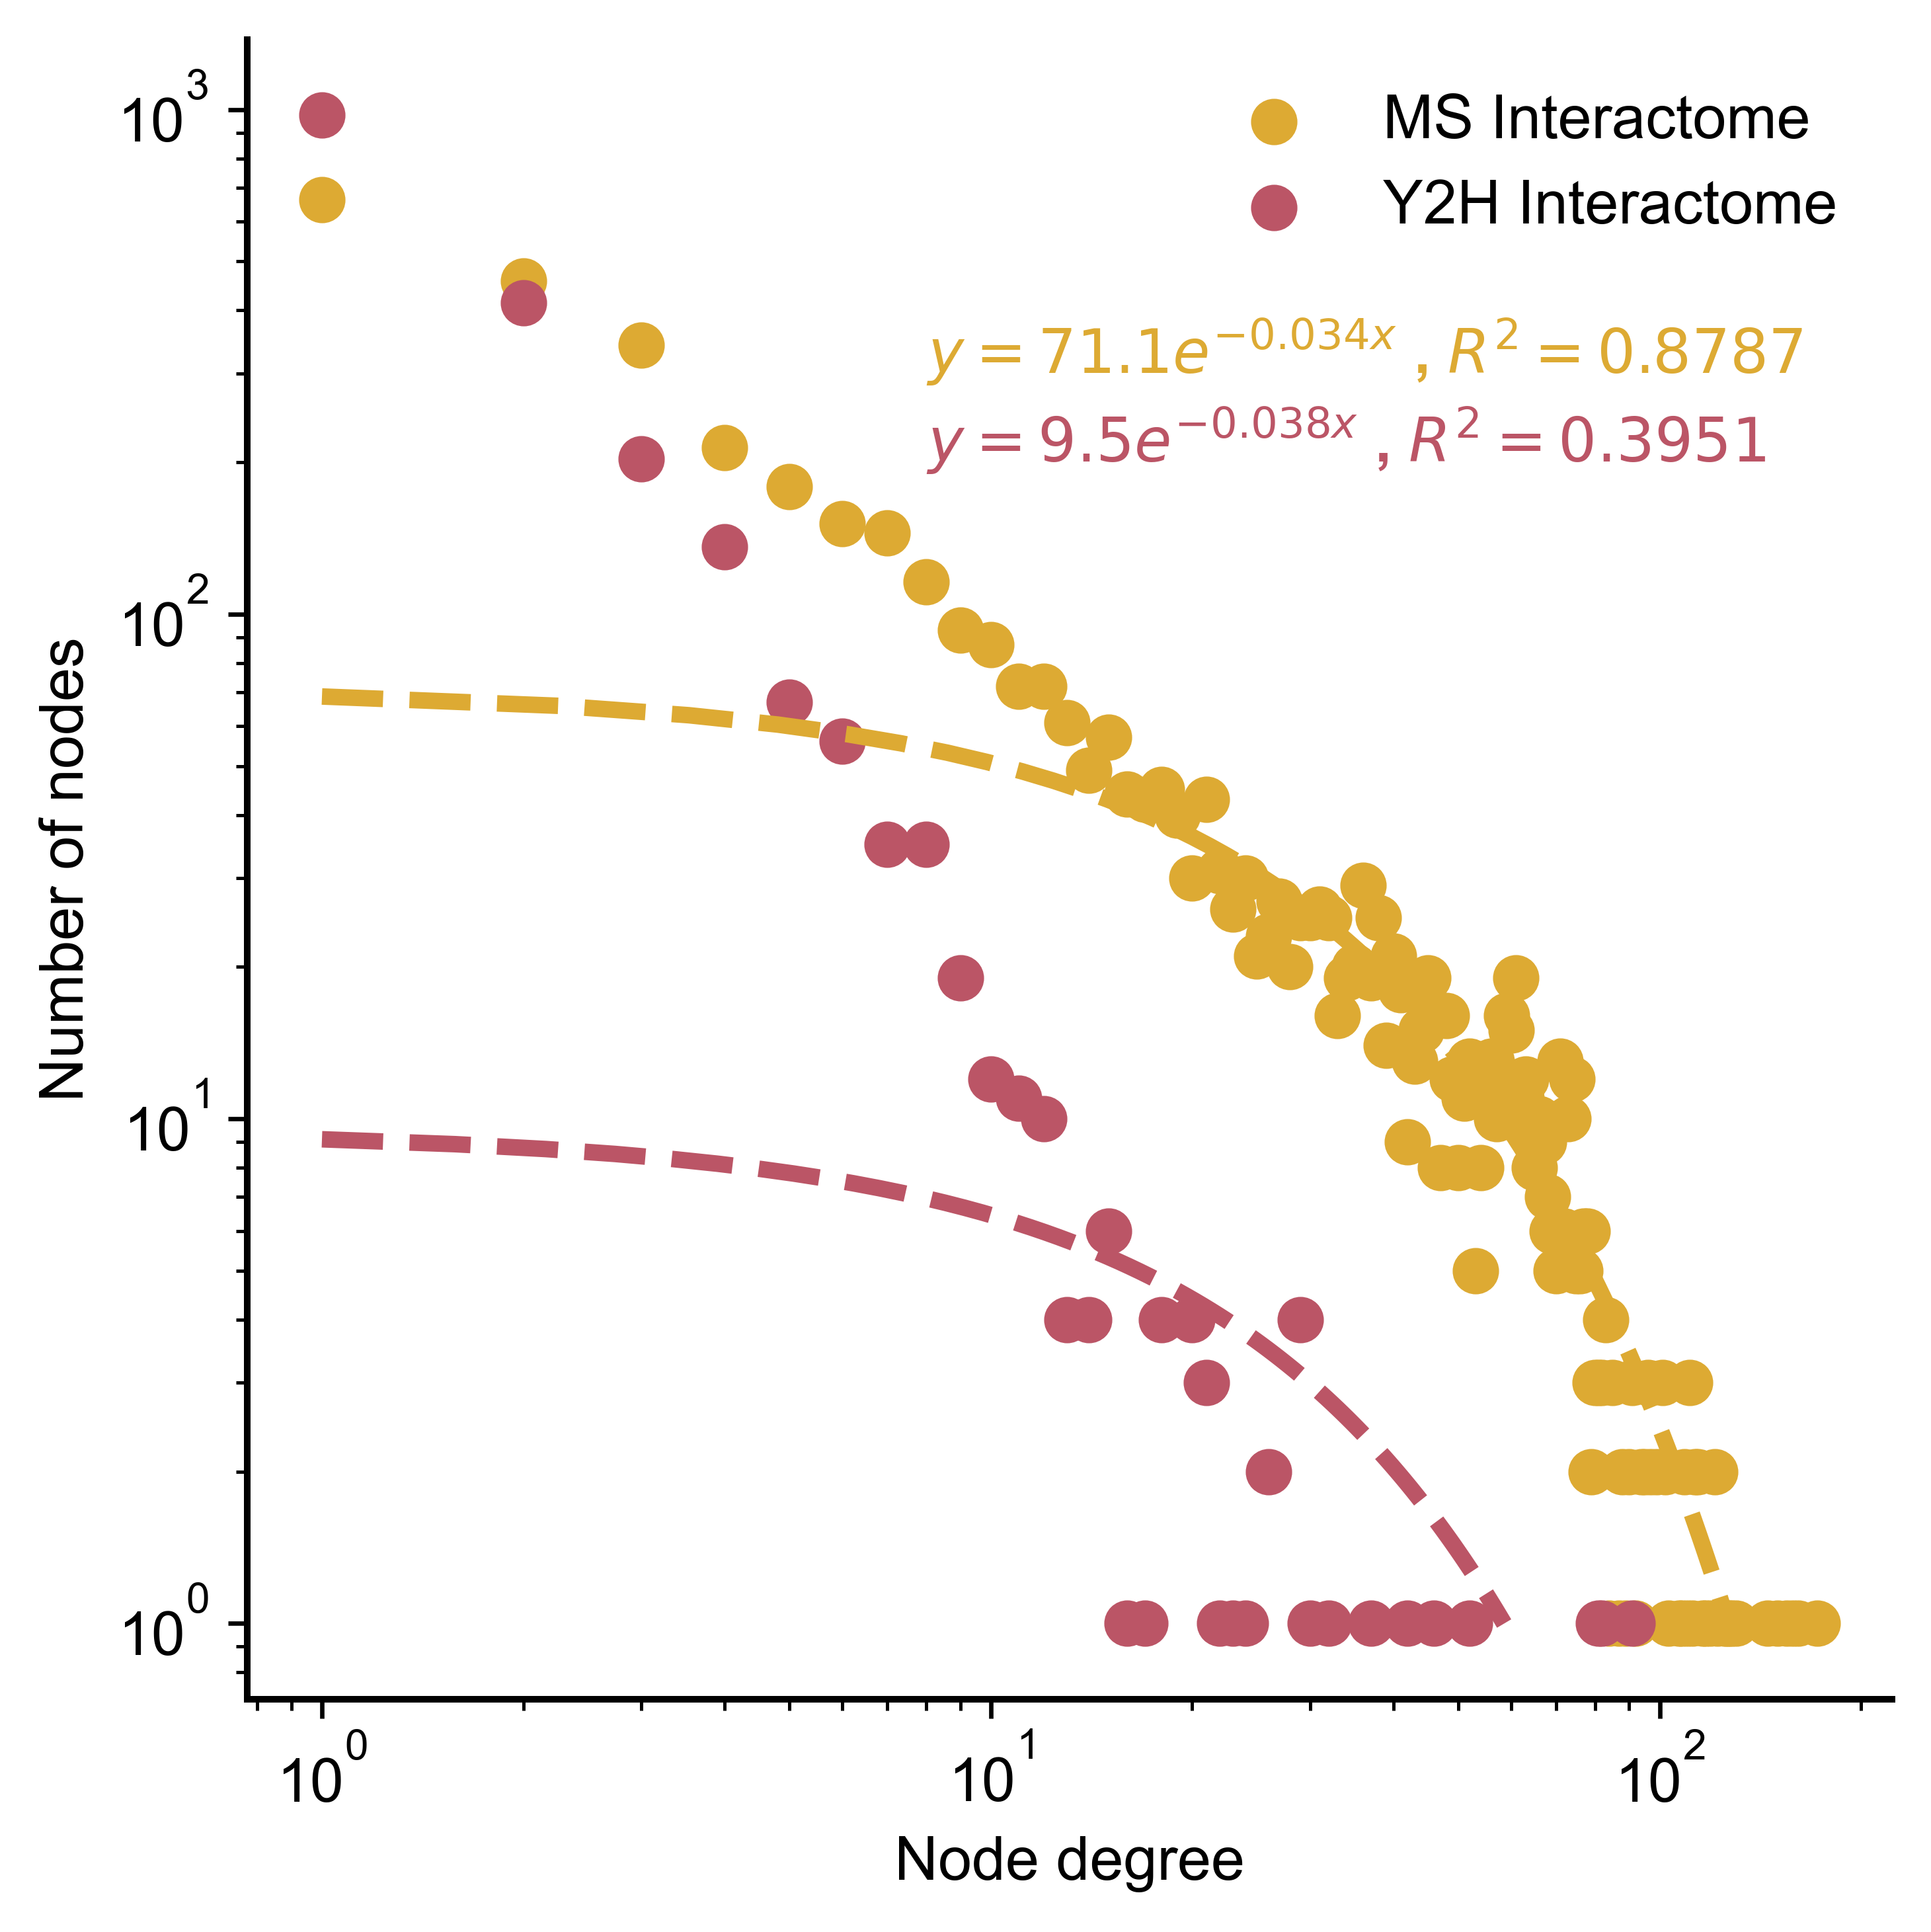

MS: a=71.053, b=-0.034, R²=0.8787
Y2H: a=9.468, b=-0.038, R²=0.3951


In [63]:
#PLOT DEGREE DISTRIBUTION ON A LOG-LOG SCALE USING EXPONENTIAL FIT
# =============================
# 1. Import Libraries & Set Global Aesthetics
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Publication-style font and axis settings
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# =============================
# 2. Define File Paths
# =============================
ms_edge_path = '/home/goel107/NCEMS/ANALYSIS/07_15_2025/The_Yeast_Interactome_edges.csv'
y2h_edge_path = '/home/goel107/NCEMS/ANALYSIS/07_15_2025/Y2H_union-clean_edges.csv'

# =============================
# 3. Helper Functions
# =============================
def split_interaction(s):
    parts = s.split(' (interacts with) ')
    return parts[0], parts[1]

def compute_degree_distribution(source_nodes, target_nodes):
    all_nodes = pd.concat([pd.Series(source_nodes), pd.Series(target_nodes)])
    degree_counts = all_nodes.value_counts().sort_index()
    unique_degrees, counts = np.unique(degree_counts.values, return_counts=True)
    return unique_degrees, counts

def exponential_fit(unique_degrees, counts, fit_range=None):
    mask = (unique_degrees > 0) & (counts > 0)
    if fit_range is not None:
        mask = mask & (unique_degrees >= fit_range[0]) & (unique_degrees <= fit_range[1])
    x = unique_degrees[mask]
    y = counts[mask]
    log_y = np.log(y)
    slope, intercept, r_value, p_value, std_err = linregress(x, log_y)
    a = np.exp(intercept)
    b = slope
    return a, b, r_value**2, x

# =============================
# 4. Load and Process Data
# =============================
# --- Mass Spec ---
df_ms = pd.read_csv(ms_edge_path)
unique_degrees_ms, counts_ms = compute_degree_distribution(df_ms['source'], df_ms['target'])

# --- Y2H ---
df_y2h = pd.read_csv(y2h_edge_path)
sources, targets = zip(*df_y2h['name'].map(split_interaction))
unique_degrees_y2h, counts_y2h = compute_degree_distribution(sources, targets)

# =============================
# 5. Publication-Quality Plotting
# =============================
fig, ax = plt.subplots(figsize=(5, 5))

# --- Plot all points ---
ax.scatter(unique_degrees_ms, counts_ms, s=55, color='#DDAA33', zorder=2, label='MS Interactome')
ax.scatter(unique_degrees_y2h, counts_y2h, s=55, color='#BB5566', zorder=2, label='Y2H Interactome')

# --- Fit exponential to MS (adjust fit range if needed) ---
a_ms, b_ms, R2_ms, x_fit_ms = exponential_fit(unique_degrees_ms, counts_ms, fit_range=(5, 200))
x_start_ms = 1
x_end_ms = -np.log(a_ms) / b_ms if b_ms != 0 else max(x_fit_ms)
x_plot_ms = np.linspace(x_start_ms, x_end_ms, 100)
y_plot_ms = a_ms * np.exp(b_ms * x_plot_ms)
ax.plot(x_plot_ms, y_plot_ms, '--', color='#DDAA33', lw=3, zorder=3)

# --- Annotate MS fit (no box) ---
eqn_str_ms = (f"$y = {a_ms:.1f} e^{{{b_ms:.3f} x}}$ , $R^2 = {R2_ms:.4f}$")
ax.annotate(eqn_str_ms, xy=(8, 300), fontsize=11, fontfamily='Arial', color='#DDAA33', zorder=10, fontweight='bold')

# --- Fit exponential to Y2H (adjust fit range if needed) ---
a_y2h, b_y2h, R2_y2h, x_fit_y2h = exponential_fit(unique_degrees_y2h, counts_y2h, fit_range=(5, 100))
x_start_y2h = 1
x_end_y2h = -np.log(a_y2h) / b_y2h if b_y2h != 0 else max(x_fit_y2h)
x_plot_y2h = np.linspace(x_start_y2h, x_end_y2h, 100)
y_plot_y2h = a_y2h * np.exp(b_y2h * x_plot_y2h)
ax.plot(x_plot_y2h, y_plot_y2h, '--', color='#BB5566', lw=3, zorder=3)

# --- Annotate Y2H fit (no box) ---
eqn_str_y2h = (f"$y = {a_y2h:.1f} e^{{{b_y2h:.3f} x}}$ , $R^2 = {R2_y2h:.4f}$")
ax.annotate(eqn_str_y2h, xy=(8, 200), fontsize=11, fontfamily='Arial', color='#BB5566', zorder=10, fontweight='bold')

# --- Axes ---
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Node degree', color='black')
ax.set_ylabel('Number of nodes', color='black')
#ax.set_title('Degree distribution', fontsize=17, loc='left', fontweight='bold')
ax.tick_params(axis='both', labelsize=11, colors='black')
ax.legend(loc='upper right', fontsize=11, frameon=False)
fig.tight_layout()

# --- Clean spines (Origin style) ---
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# --- Save and/or show ---
pd.DataFrame({'degree': unique_degrees_ms, 'count': counts_ms}).to_csv("ms_degree.csv", index=False)
pd.DataFrame({'degree': unique_degrees_y2h, 'count': counts_y2h}).to_csv("y2h_degree.csv", index=False)
fig.savefig("/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE1/1D-log-log_plot(exponential-fit).svg", dpi=300, bbox_inches='tight')
plt.show()

# =============================
# 6. Output Fit Parameters (if needed)
# =============================
print(f"MS: a={a_ms:.3f}, b={b_ms:.3f}, R²={R2_ms:.4f}")
print(f"Y2H: a={a_y2h:.3f}, b={b_y2h:.3f}, R²={R2_y2h:.4f}")

In [59]:
# COMPUTE ISOLATED NODES IN MS and Y2H THAT DO NOT INTERACT IN INTEARCTION NETWORK
# For MS
ms_edge_nodes = set(df_ms_filtered['source']).union(df_ms_filtered['target'])
ms_isolated_nodes = nodes_ms_filtered - ms_edge_nodes
print(f"MS isolated nodes (not in edges): {len(ms_isolated_nodes)}")
print(f"MS isolated nodes: {ms_isolated_nodes}")

# For Y2H
y2h_edge_nodes = set(s for s, t in filtered_y2h_edges).union(t for s, t in filtered_y2h_edges)
y2h_isolated_nodes = nodes_y2h_filtered - y2h_edge_nodes
print(f"Y2H isolated nodes (not in edges): {len(y2h_isolated_nodes)}")
print(f"Y2H isolated nodes: {y2h_isolated_nodes}")

MS isolated nodes (not in edges): 26
MS isolated nodes: {'YHR063C', 'YKR099W', 'YDR400W', 'YOR221C', 'YDR300C', 'YGL126W', 'YGR152C', 'YDL146W', 'YGR052W', 'YGR295C', 'YPR129W', 'YNL154C', 'YPR081C', 'YDR132C', 'YDL173W', 'YGL185C', 'YKL113C', 'YBL013W', 'YPL097W', 'YDR104C', 'YLR190W', 'YPL072W', 'YPL112C', 'YOR193W', 'YDL238C', 'YNL053W'}
Y2H isolated nodes (not in edges): 151
Y2H isolated nodes: {'YBR156C', 'YBR253W', 'YIL084C', 'YDL076C', 'YMR288W', 'YKR024C', 'YDL056W', 'YJL047C', 'YMR280C', 'YJR117W', 'YPL269W', 'YBL091C', 'YEL060C', 'YJR009C', 'YMR275C', 'YJR121W', 'YMR213W', 'YBR123C', 'YGR155W', 'YNL181W', 'YKL074C', 'YHR197W', 'YBR038W', 'YDL161W', 'YOL020W', 'YOL088C', 'YFL042C', 'YPR022C', 'YOR329C', 'YNL075W', 'YCR057C', 'YJR125C', 'YBL039C', 'YML075C', 'YGL030W', 'YNL279W', 'YGL247W', 'YDR183W', 'YGL070C', 'YCR027C', 'YNL131W', 'YDR240C', 'YGR081C', 'YGL086W', 'YOR281C', 'YDL146W', 'YMR060C', 'YOR308C', 'YLR439W', 'YDL073W', 'YPR149W', 'YLR403W', 'YDR116C', 'YBR102C', 'YH

In [61]:
#COMPUTE NODES AND EDGES IN THE MS & Y2H OVERLAP NMETWORK
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# Assume selected_columns is already loaded with filtered proteins
valid_nodes = set(selected_columns['node'])

# === 1. Filter edges to keep only those with both nodes in valid_nodes ===

# Filter MS edges
df_ms_filtered = df_ms[df_ms['source'].isin(valid_nodes) & df_ms['target'].isin(valid_nodes)]

# Filter Y2H edges
filtered_y2h_edges = [(s, t) for s, t in zip(sources, targets) if s in valid_nodes and t in valid_nodes]

# === 2. Make a set of edges (as sorted tuples) for both filtered networks ===

edges_ms = set(tuple(sorted([row['source'], row['target']])) for _, row in df_ms_filtered.iterrows())
edges_y2h = set(tuple(sorted([s, t])) for s, t in filtered_y2h_edges)

# === 3. Intersection (common edges only) ===
edges_intersection = edges_ms & edges_y2h

print(f"Number of common edges (interactions): {len(edges_intersection)}")

# === 4. Build the consensus/intersection network ===
G_overlap = nx.Graph()
G_overlap.add_edges_from(edges_intersection)

print(f"Number of nodes in overlap network: {G_overlap.number_of_nodes()}")

# === 5. Extract largest connected component (LCC) ===
if G_overlap.number_of_nodes() > 0:
    largest_cc_overlap = max(nx.connected_components(G_overlap), key=len)
    G_overlap_lcc = G_overlap.subgraph(largest_cc_overlap).copy()
    print(f"Largest connected component size: {G_overlap_lcc.number_of_nodes()} nodes, {G_overlap_lcc.number_of_edges()} edges")
else:
    print("No overlap between MS and Y2H networks!")

# === 6. Plot the largest connected component of overlap network ===
#if G_overlap.number_of_nodes() > 0:
    #plt.figure(figsize=(8, 8))
    #pos = nx.spring_layout(G_overlap_lcc, seed=42, k=0.18)
    #nx.draw_networkx_nodes(G_overlap_lcc, pos, node_size=40, alpha=0.8, node_color="#8888FF")
    #nx.draw_networkx_edges(G_overlap_lcc, pos, width=0.6, alpha=0.5, edge_color="#333377")
    #plt.title("Largest Connected Component: Intersection of MS & Y2H (Filtered)", fontsize=15)
    #plt.axis("off")
    #plt.tight_layout()
    #plt.show()

# List proteins in intersection network
proteins_in_overlap = list(G_overlap.nodes())
print(f"Total proteins in overlap network: {len(proteins_in_overlap)}")
print(proteins_in_overlap[:10])

Number of common edges (interactions): 430
Number of nodes in overlap network: 657
Largest connected component size: 10 nodes, 12 edges
Total proteins in overlap network: 657
['YDR473C', 'YPR178W', 'YEL034W', 'YHR068W', 'YER157W', 'YGR120C', 'YEL048C', 'YMR218C', 'YMR129W', 'YMR153W']


In [66]:
#COMPUTE HUBS IN EACH NETWORK
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# Assuming selected_columns, df_ms, sources, targets are defined
# Set of valid filtered nodes from your EDA dataframe
valid_nodes = set(selected_columns['node'])

# Step 1: Filter edges to keep only those with both nodes in valid_nodes
df_ms_filtered = df_ms[df_ms['source'].isin(valid_nodes) & df_ms['target'].isin(valid_nodes)]
filtered_y2h_edges = [(s, t) for s, t in zip(sources, targets) if s in valid_nodes and t in valid_nodes]

# Step 2: Create edge sets (sorted tuples for undirected edges) and remove self-loops
edges_ms = {tuple(sorted([row['source'], row['target']])) for _, row in df_ms_filtered.iterrows() if row['source'] != row['target']}
edges_y2h = {tuple(sorted([s, t])) for s, t in filtered_y2h_edges if s != t}

# Step 3: Compute edge union and intersection
edges_union = edges_ms | edges_y2h
edges_intersection = edges_ms & edges_y2h
edge_overlap_percent = (len(edges_intersection) / len(edges_union)) * 100 if edges_union else 0

# Step 4: Build graphs
G_ms = nx.from_pandas_edgelist(df_ms_filtered, 'source', 'target')
G_y2h = nx.Graph()
G_y2h.add_edges_from(filtered_y2h_edges)

# Step 5: Compute descriptors (degree and betweenness; add other 7 metrics if needed)
descriptors_ms = pd.DataFrame({
    'node': list(G_ms.nodes()),
    'degree': [G_ms.degree(n) for n in G_ms.nodes()],
    'betweenness': nx.betweenness_centrality(G_ms).values()
})
descriptors_y2h = pd.DataFrame({
    'node': list(G_y2h.nodes()),
    'degree': [G_y2h.degree(n) for n in G_y2h.nodes()],
    'betweenness': nx.betweenness_centrality(G_y2h).values()
})

# Step 6: Identify common nodes
common_nodes = set(descriptors_ms['node']) & set(descriptors_y2h['node'])

# Step 7: Filter descriptors to common nodes for fair comparison
descriptors_ms = descriptors_ms[descriptors_ms['node'].isin(common_nodes)]
descriptors_y2h = descriptors_y2h[descriptors_y2h['node'].isin(common_nodes)]

# Step 8: Define hubs (top 10% by degree)
num_nodes = len(common_nodes)
top_percent = 0.10
hub_threshold_ms = descriptors_ms['degree'].quantile(1 - top_percent)
hub_threshold_y2h = descriptors_y2h['degree'].quantile(1 - top_percent)

hubs_ms = descriptors_ms[descriptors_ms['degree'] >= hub_threshold_ms]['node'].tolist()
hubs_y2h = descriptors_y2h[descriptors_y2h['degree'] >= hub_threshold_y2h]['node'].tolist()

# Step 9: Compute hub intersection and union
common_hubs = set(hubs_ms) & set(hubs_y2h)
all_hubs = set(hubs_ms) | set(hubs_y2h)
hub_overlap_percentage = (len(common_hubs) / len(all_hubs)) * 100 if len(all_hubs) > 0 else 0

# Step 10: Print all statistics
print("=== Network Edge Statistics ===")
print(f"Number of edges in MS (filtered): {len(edges_ms)}")
print(f"Number of edges in Y2H (filtered): {len(edges_y2h)}")
print(f"Number of edges in union: {len(edges_union)}")
print(f"Number of edges in intersection: {len(edges_intersection)}")
print(f"Edge overlap percentage (intersection/union): {edge_overlap_percent:.2f}%")

print("\n=== Hub Statistics ===")
print(f"Number of common nodes: {num_nodes}")
print(f"Number of hubs in MS: {len(hubs_ms)}")
print(f"Number of hubs in Y2H: {len(hubs_y2h)}")
print(f"Number of common hubs (intersection): {len(common_hubs)}")
print(f"Number of all relevant hubs (union): {len(all_hubs)}")
print(f"Hub overlap percentage (intersection/union): {hub_overlap_percentage:.2f}%")
print(f"Example MS hubs: {hubs_ms[:5]}")
print(f"Example Y2H hubs: {hubs_y2h[:5]}")

=== Network Edge Statistics ===
Number of edges in MS (filtered): 29490
Number of edges in Y2H (filtered): 1556
Number of edges in union: 30616
Number of edges in intersection: 430
Edge overlap percentage (intersection/union): 1.40%

=== Hub Statistics ===
Number of common nodes: 1303
Number of hubs in MS: 138
Number of hubs in Y2H: 155
Number of common hubs (intersection): 11
Number of all relevant hubs (union): 282
Hub overlap percentage (intersection/union): 3.90%
Example MS hubs: ['YKR066C', 'YLR421C', 'YLR216C', 'YJL001W', 'YMR024W']
Example Y2H hubs: ['YJL112W', 'YMR124W', 'YAL032C', 'YDR416W', 'YDR448W']


Total hubs analyzed: 282
Similar hubs (Jaccard > 0.3): 8
MS dominant dissimilar hubs: 183
Y2H dominant dissimilar hubs: 80
Percentage of hubs with similar connectivity: 2.84%
Similar hubs (nodes): ['YNL124W', 'YKR037C', 'YPL031C', 'YNL078W', 'YBR135W', 'YJR102C', 'YIL033C', 'YHR068W']

Preview of similarity metrics (first 10 rows):
      node  degree_ms  degree_y2h  degree_diff  betweenness_ms  \
0  YKR048C         20          13     0.086797        0.003231   
1  YGR158C         56           3     0.313636        0.000062   
2  YLR421C         40           1     0.243074        0.002222   
3  YLR275W         67           1     0.418398        0.004656   
4  YDL147W         47           1     0.288528        0.003863   
5  YMR308C         17           5     0.027056        0.002155   
6  YBR261C          1          26     0.426840        0.000000   
7  YLR258W         12           7     0.038745        0.001478   
8  YGL187C         44           4     0.219048        0.001326   
9  YJR

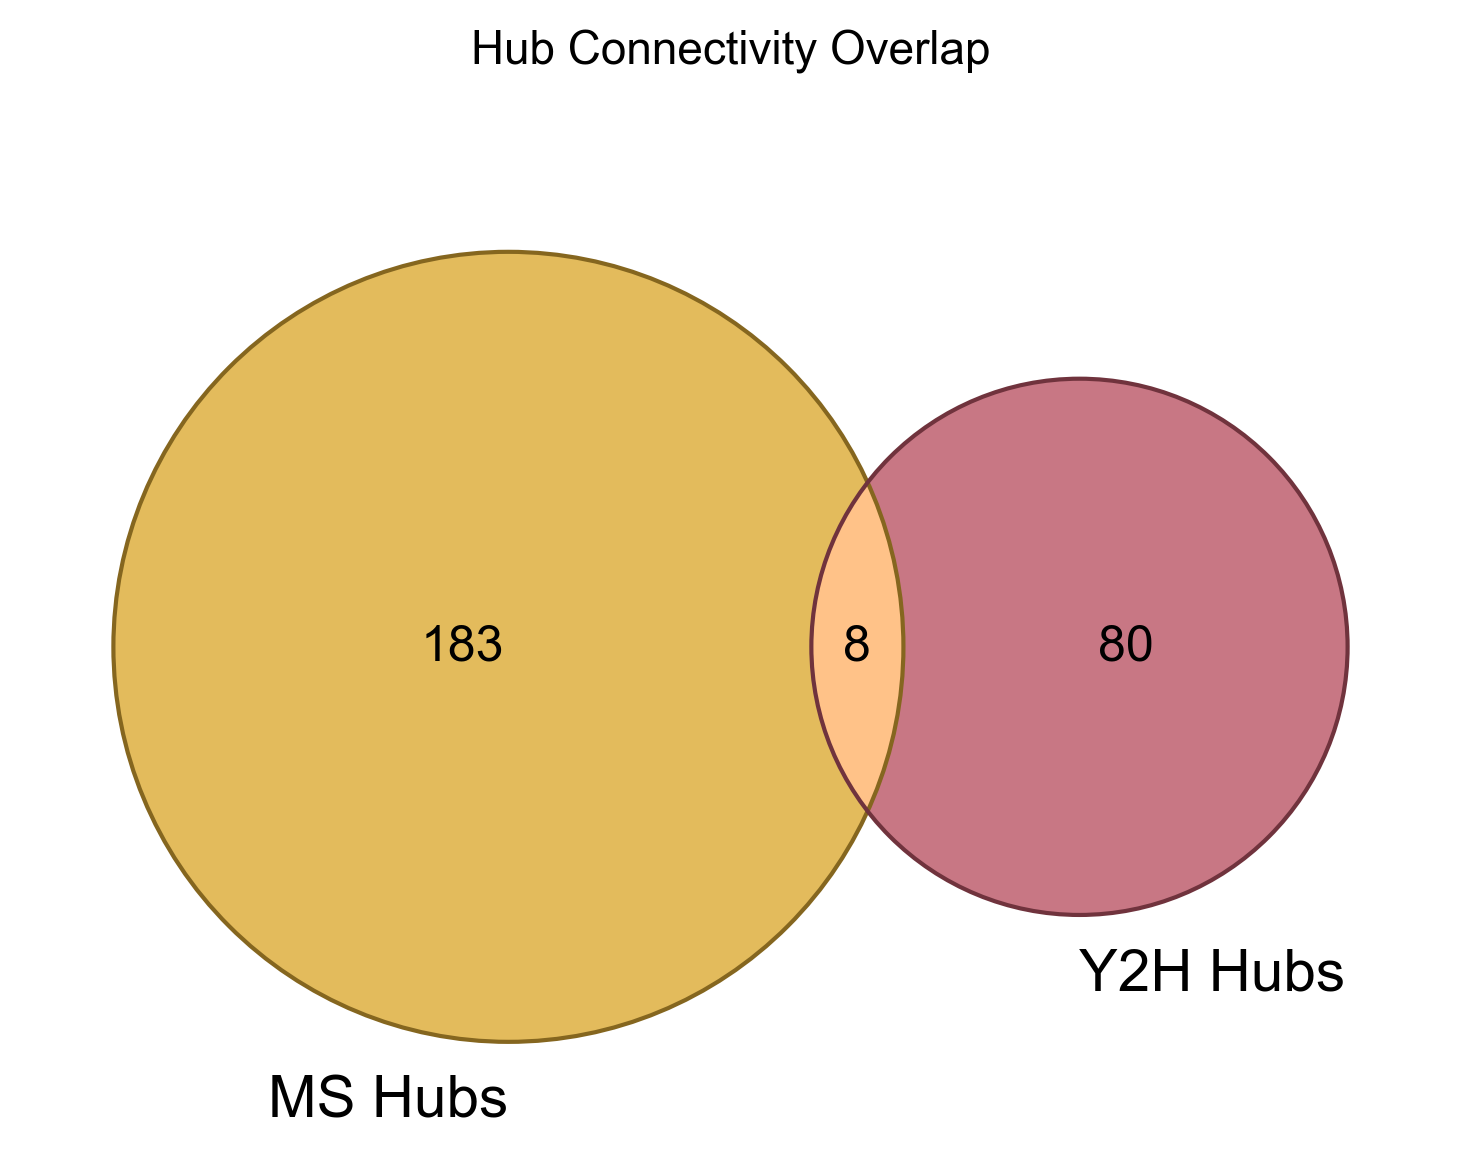

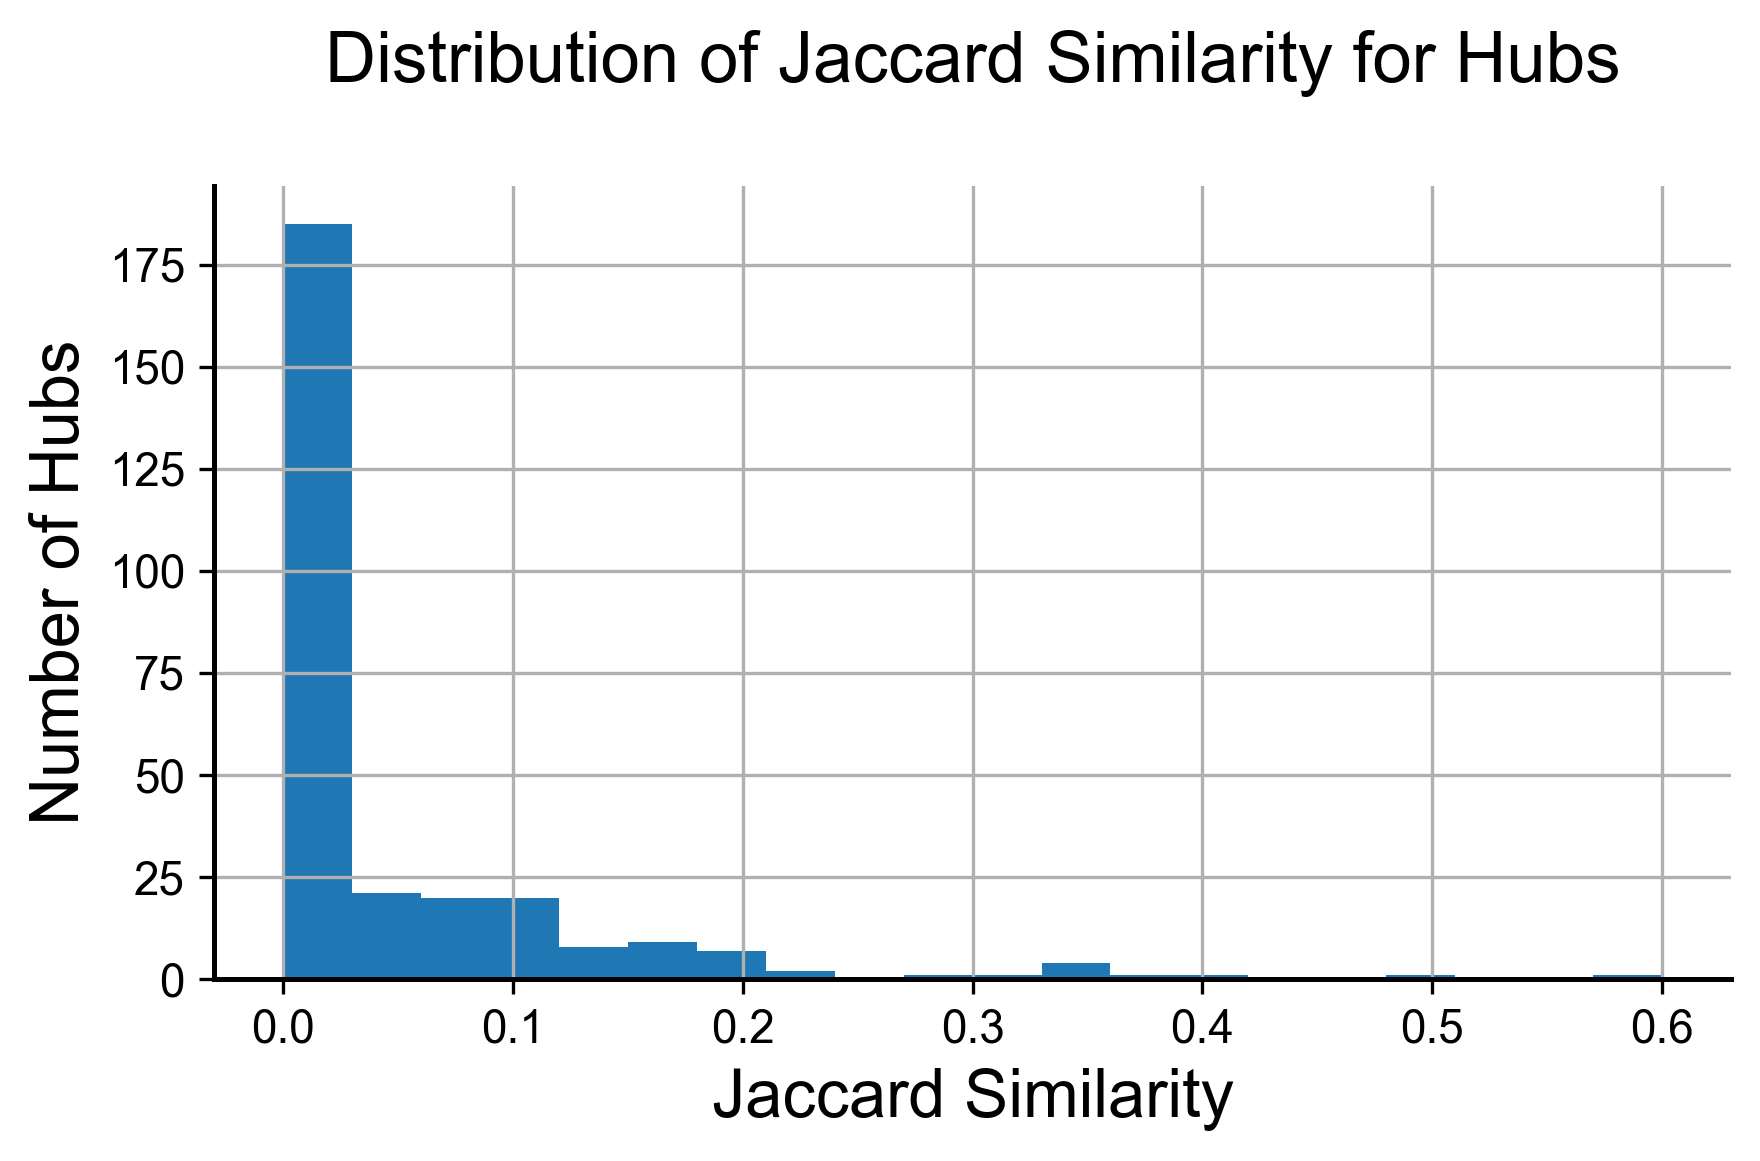

In [71]:
#COMPUTE HUB CONNECTIVITY OVERLAP BASED ON JACCARD SIMILARITY INDEX
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles
from matplotlib.colors import to_rgb, rgb_to_hsv, hsv_to_rgb
import numpy as np

# Set Global Aesthetics
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# Function to darken a color
def darken_color(color, factor=0.6):
    rgb = to_rgb(color)
    hsv = rgb_to_hsv(rgb)
    # Reduce value (brightness) to darken
    hsv = (hsv[0], hsv[1], hsv[2] * factor)
    return hsv_to_rgb(hsv)

# Assuming G_ms, G_y2h, descriptors_ms, descriptors_y2h, all_hubs are defined
# Ensure descriptors_ms and descriptors_y2h have 'node', 'degree', 'betweenness' for common nodes
# Create a DataFrame to store similarity metrics for all hubs
similarity_df = pd.DataFrame(all_hubs, columns=['node'])

# Merge degree and betweenness from both networks
similarity_df = similarity_df.merge(
    descriptors_ms[['node', 'degree', 'betweenness']],
    on='node', how='left', suffixes=('', '_ms')
).merge(
    descriptors_y2h[['node', 'degree', 'betweenness']],
    on='node', how='left', suffixes=('_ms', '_y2h')
)

# Fill NaN for non-hubs (e.g., hub in MS but not Y2H)
similarity_df.fillna({'degree_ms': 0, 'betweenness_ms': 0, 'degree_y2h': 0, 'betweenness_y2h': 0}, inplace=True)

# Normalize metrics (divide by max in each network)
max_degree_ms = descriptors_ms['degree'].max()
max_degree_y2h = descriptors_y2h['degree'].max()
max_betweenness_ms = descriptors_ms['betweenness'].max()
max_betweenness_y2h = descriptors_y2h['betweenness'].max()
similarity_df['norm_degree_ms'] = similarity_df['degree_ms'] / max_degree_ms
similarity_df['norm_degree_y2h'] = similarity_df['degree_y2h'] / max_degree_y2h
similarity_df['norm_betweenness_ms'] = similarity_df['betweenness_ms'] / max_betweenness_ms
similarity_df['norm_betweenness_y2h'] = similarity_df['betweenness_y2h'] / max_betweenness_y2h

# Compute differences
similarity_df['degree_diff'] = abs(similarity_df['norm_degree_ms'] - similarity_df['norm_degree_y2h'])
similarity_df['betweenness_diff'] = abs(similarity_df['norm_betweenness_ms'] - similarity_df['norm_betweenness_y2h'])

# Compute Jaccard similarity for neighbor overlap
def jaccard_similarity(g1, g2, node):
    try:
        neighbors1 = set(g1.neighbors(node))
        neighbors2 = set(g2.neighbors(node))
        intersection = len(neighbors1 & neighbors2)
        union = len(neighbors1 | neighbors2)
        return intersection / union if union > 0 else 0
    except nx.NetworkXError:
        return 0  # If node not in graph, assume no overlap

similarity_df['jaccard'] = similarity_df['node'].apply(lambda x: jaccard_similarity(G_ms, G_y2h, x))

# Define "similar" hubs with thresholds
degree_threshold = 0.2
betweenness_threshold = 0.2
jaccard_threshold = 0.3  # Matches your result of 8 similar hubs
similarity_df['is_similar'] = (
    (similarity_df['degree_diff'] < degree_threshold) &
    (similarity_df['betweenness_diff'] < betweenness_threshold) &
    (similarity_df['jaccard'] > jaccard_threshold)
)

# Calculate counts
total_hubs = len(similarity_df)  # Should be 282
similar_hubs = similarity_df['is_similar'].sum()

# Classify dissimilar hubs based on degree dominance
similarity_df['is_ms_dominant'] = (similarity_df['degree_ms'] > similarity_df['degree_y2h']) & (~similarity_df['is_similar'])
similarity_df['is_y2h_dominant'] = (similarity_df['degree_y2h'] > similarity_df['degree_ms']) & (~similarity_df['is_similar'])
ms_dominant_hubs = similarity_df['is_ms_dominant'].sum()
y2h_dominant_hubs = similarity_df['is_y2h_dominant'].sum()

# Output statistics
print(f"Total hubs analyzed: {total_hubs}")
print(f"Similar hubs (Jaccard > {jaccard_threshold}): {similar_hubs}")
print(f"MS dominant dissimilar hubs: {ms_dominant_hubs}")
print(f"Y2H dominant dissimilar hubs: {y2h_dominant_hubs}")
print(f"Percentage of hubs with similar connectivity: {(similar_hubs / total_hubs) * 100:.2f}%")
print(f"Similar hubs (nodes): {similarity_df[similarity_df['is_similar']]['node'].tolist()}")
print("\nPreview of similarity metrics (first 10 rows):")
print(similarity_df[['node', 'degree_ms', 'degree_y2h', 'degree_diff', 'betweenness_ms', 'betweenness_y2h', 'betweenness_diff', 'jaccard', 'is_similar']].head(10))

# Save to CSV for inspection (optional)
similarity_df.to_csv('hub_similarity_metrics.csv', index=False)

# Colors
color_ms = '#DDAA33'
color_y2h = '#BB5566'
# Darken colors for outlines
ms_edge_color = darken_color(color_ms, factor=0.6)
y2h_edge_color = darken_color(color_y2h, factor=0.6)

# Venn diagram
fig_venn = plt.figure(figsize=(5, 5))
ax_venn = fig_venn.add_subplot(111)
# Calculate sets for Venn diagram
ms_hubs = similarity_df[similarity_df['degree_ms'] > 0]['node'].count()  # All MS hubs
y2h_hubs = similarity_df[similarity_df['degree_y2h'] > 0]['node'].count()  # All Y2H hubs
overlap = similar_hubs  # Similar hubs are in both MS and Y2H
ms_only = ms_dominant_hubs  # MS-dominant dissimilar hubs
y2h_only = y2h_dominant_hubs  # Y2H-dominant dissimilar hubs
# Create Venn diagram
venn = venn2(subsets=(ms_only, y2h_only, overlap), set_labels=('MS Hubs', 'Y2H Hubs'), set_colors=(color_ms, color_y2h), alpha=0.8, ax=ax_venn)
venn.get_label_by_id('10').set_text(str(ms_only))  # MS only
venn.get_label_by_id('01').set_text(str(y2h_only))  # Y2H only
venn.get_label_by_id('11').set_text(str(overlap))  # Common
c = venn2_circles(subsets=(ms_only, y2h_only, overlap), linestyle='solid', linewidth=1, ax=ax_venn)
c[0].set_edgecolor(ms_edge_color)  # Darker MS outline
c[1].set_edgecolor(y2h_edge_color)  # Darker Y2H outline
# Customize labels
for text in venn.set_labels:
    if text: text.set_fontsize(14)
for text in venn.subset_labels:
    if text: text.set_fontsize(12)
ax_venn.set_title(f'Hub Connectivity Overlap', fontsize=11)
plt.tight_layout()
plt.savefig('/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE1/1E-venn-diagram.svg', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

# Jaccard histogram
fig_hist = plt.figure(figsize=(6, 4))
ax_hist = fig_hist.add_subplot(111)
similarity_df['jaccard'].hist(bins=20, ax=ax_hist)
ax_hist.set_xlabel('Jaccard Similarity', fontsize=16)
ax_hist.set_ylabel('Number of Hubs', fontsize=16)
ax_hist.set_title('Distribution of Jaccard Similarity for Hubs', fontsize=17)
plt.tight_layout()
#plt.savefig('jaccard_histogram.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

In [ ]:
# =============================
# 1. Import Libraries & Set Global Aesthetics
# =============================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy.stats import mannwhitneyu

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

sns.set_style('white')

# =============================
# 2. Define Features & Group Cuts
# =============================
abundance_features = ['Mean_molecules_per_cell', 'Median_molecules_per_cell', 'Rosetta_total_score', 'FoldX_total_energy', 'Ghosh-Dill-dG', 'cagiada-dG']
centrality_cuts = {
    "High Degree": ("MS_degree_centrality_percentile", 90),
    "High Betweenness": ("MS_betweenness_centrality_percentile", 90)
}
centrality_groups = {
    "Top 10% Degree":   ("MS_degree_centrality_percentile", 90, '>='),
    "Bottom 90% Degree": ("MS_degree_centrality_percentile", 90, '<'),
    "Top 10% Betweenness":   ("MS_betweenness_centrality_percentile", 90, '>='),
    "Bottom 90% Betweenness": ("MS_betweenness_centrality_percentile", 90, '<'),
}
group_colors = ['#997700', '#EECC66']

# =============================
# 3. Panel Setup
# =============================
n_features = len(abundance_features)
n_panels = 2  # Degree and Betweenness
fig, axes = plt.subplots(n_panels, n_features, figsize=(4.5*n_features, 6*n_panels), sharey=False)
if n_features == 1:
    axes = np.array([[axes[0]], [axes[1]]])

# =============================
# 4. Plotting Loop
# =============================
for feat_idx, feature in enumerate(abundance_features):
    # DEGREE PANEL (row 0)
    ax = axes[0, feat_idx]
    data = []
    group_labels = ["Top 10%", "Bottom 90%"]
    for idx, (group, (cent_col, cutoff, operator)) in enumerate(list(centrality_groups.items())[:2]):  # Degree groups
        group_mask = (selected_columns[cent_col] >= cutoff) if operator == '>=' else (selected_columns[cent_col] < cutoff)
        group_values = pd.to_numeric(selected_columns.loc[group_mask, feature], errors='coerce').dropna()
        data.append(group_values)
    b = ax.boxplot(
        data, patch_artist=True, labels=group_labels, showfliers=False, widths=0.75,
        boxprops=dict(linewidth=1.2, color='black'), medianprops=dict(linewidth=1.5, color='black'),
        whiskerprops=dict(linewidth=1.2, color='black'), capprops=dict(linewidth=1.2, color='black')
    )
    group_colors = ['#997700', '#EECC66']
    for patch, color in zip(b['boxes'], group_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    # Y-label for every plot
    ax.set_ylabel(feature.replace('_', ' '), fontsize=15, color='black')
    ax.tick_params(axis='both', labelsize=12, colors='black')
    # -- Simple x-tick labels
    ax.set_xticklabels(group_labels, fontsize=13, color='black')
    # -- Centrality type centered under plot
    ax.set_xlabel("Degree Centrality", fontsize=14, color='black', fontweight='bold', labelpad=16)

    # Clean spines, etc.
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.grid(False)

    # Mann Whitney U test
    if len(data[0]) > 0 and len(data[1]) > 0:
        stat, pval = mannwhitneyu(data[0], data[1], alternative='two-sided')
        print(f"Degree: {feature}: Mann-Whitney U = {stat:.2e}, p = {pval:.2g}")

    # BETWEenness PANEL (row 1)
    ax = axes[1, feat_idx]
    data = []
    group_labels = ["Top 10%", "Bottom 90%"]
    for idx, (group, (cent_col, cutoff, operator)) in enumerate(list(centrality_groups.items())[2:]):  # Betweenness groups
        group_mask = (selected_columns[cent_col] >= cutoff) if operator == '>=' else (selected_columns[cent_col] < cutoff)
        group_values = pd.to_numeric(selected_columns.loc[group_mask, feature], errors='coerce').dropna()
        data.append(group_values)
    b = ax.boxplot(
        data, patch_artist=True, labels=group_labels, showfliers=False, widths=0.75,
        boxprops=dict(linewidth=1.2, color='black'), medianprops=dict(linewidth=1.5, color='black'),
        whiskerprops=dict(linewidth=1.2, color='black'), capprops=dict(linewidth=1.2, color='black')
    )
    for patch, color in zip(b['boxes'], group_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel(feature.replace('_', ' '), fontsize=15, color='black')
    ax.tick_params(axis='both', labelsize=12, colors='black')
    # -- Simple x-tick labels
    ax.set_xticklabels(group_labels, fontsize=13, color='black')
    # -- Centrality type centered under plot
    ax.set_xlabel("Betweenness Centrality", fontsize=14, color='black', fontweight='bold', labelpad=16)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.grid(False)

    # Mann Whitney U test
    if len(data[0]) > 0 and len(data[1]) > 0:
        stat, pval = mannwhitneyu(data[0], data[1], alternative='two-sided')
        print(f"Betweenness: {feature}: Mann-Whitney U = {stat:.2e}, p = {pval:.2g}")

    # Optionally: add swarm for points
    # for i, group_vals in enumerate(data):
    #     ax.scatter(np.full_like(group_vals, i+1, dtype=float)+np.random.normal(0,0.03,len(group_vals)), group_vals, color='k', alpha=0.12, s=10)

# =============================
# 5. Title and Layout
# =============================
fig.suptitle(
    'Abundance & Stability Features: Top 10% vs Bottom 90% of Degree/Betweenness Centrality',
    fontsize=16, y=1.03, color='black', fontweight='bold'
)
plt.tight_layout(rect=[0, 0.04, 1, 0.98])
plt.show()

# =============================
# 6. Saving Individual Plots
# =============================

save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025"  # <-- update this to your desired directory
os.makedirs(save_dir, exist_ok=True)

group_labels = ["Top 10%", "Bottom 90%"]
group_colors = ['#997700', '#EECC66']
plot_idx = 1

for feat_idx, feature in enumerate(abundance_features):
    # DEGREE INDIVIDUAL
    data_deg = []
    for idx, (group, (cent_col, cutoff, operator)) in enumerate(list(centrality_groups.items())[:2]):
        group_mask = (selected_columns[cent_col] >= cutoff) if operator == '>=' else (selected_columns[cent_col] < cutoff)
        group_values = pd.to_numeric(selected_columns.loc[group_mask, feature], errors='coerce').dropna()
        data_deg.append(group_values)
    fig, ax = plt.subplots(figsize=(4.5, 6))
    b = ax.boxplot(
        data_deg, patch_artist=True, labels=group_labels, showfliers=False, widths=0.75,
        boxprops=dict(linewidth=1.2, color='black'), medianprops=dict(linewidth=1.5, color='black'),
        whiskerprops=dict(linewidth=1.2, color='black'), capprops=dict(linewidth=1.2, color='black')
    )
    for patch, color in zip(b['boxes'], group_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel(feature.replace('_', ' '), fontsize=15, color='black')
    ax.tick_params(axis='both', labelsize=12, colors='black')
    ax.set_xticklabels(group_labels, fontsize=13, color='black')
    ax.set_xlabel("Degree Centrality", fontsize=14, color='black', fontweight='bold', labelpad=16)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.grid(False)

    # Save as PNG
    safe_feat = feature.replace('/', '_').replace(' ', '_')
    filename = f"2A{plot_idx}-DegreeCentrality-{safe_feat}.png"
    fig.savefig(os.path.join(save_dir, filename), dpi=600, bbox_inches='tight')
    plt.close(fig)
    plot_idx += 1

    # BETWEEnness INDIVIDUAL
    data_bet = []
    for idx, (group, (cent_col, cutoff, operator)) in enumerate(list(centrality_groups.items())[2:]):
        group_mask = (selected_columns[cent_col] >= cutoff) if operator == '>=' else (selected_columns[cent_col] < cutoff)
        group_values = pd.to_numeric(selected_columns.loc[group_mask, feature], errors='coerce').dropna()
        data_bet.append(group_values)
    fig, ax = plt.subplots(figsize=(4.5, 6))
    b = ax.boxplot(
        data_bet, patch_artist=True, labels=group_labels, showfliers=False, widths=0.75,
        boxprops=dict(linewidth=1.2, color='black'), medianprops=dict(linewidth=1.5, color='black'),
        whiskerprops=dict(linewidth=1.2, color='black'), capprops=dict(linewidth=1.2, color='black')
    )
    for patch, color in zip(b['boxes'], group_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel(feature.replace('_', ' '), fontsize=15, color='black')
    ax.tick_params(axis='both', labelsize=12, colors='black')
    ax.set_xticklabels(group_labels, fontsize=13, color='black')
    ax.set_xlabel("Betweenness Centrality", fontsize=14, color='black', fontweight='bold', labelpad=16)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.grid(False)

    # Save as PNG
    filename = f"2A{plot_idx}-BetweennessCentrality-{safe_feat}.png"
    fig.savefig(os.path.join(save_dir, filename), dpi=600, bbox_inches='tight')
    plt.close(fig)
    plot_idx += 1

In [ ]:
# =============================
# 1. Import Libraries & Set Global Aesthetics
# =============================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy.stats import mannwhitneyu

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

sns.set_style('white')

# =============================
# 2. Define Features & Group Cuts
# =============================
abundance_features = ['Mean_molecules_per_cell', 'Median_molecules_per_cell', 'Rosetta_total_score', 'FoldX_total_energy', 'Ghosh-Dill-dG', 'cagiada-dG']
centrality_cuts = {
    "High Degree": ("Y2H_degree_centrality_percentile", 90),
    "High Betweenness": ("Y2H_betweenness_centrality_percentile", 90)
}
centrality_groups = {
    "Top 10% Degree":   ("Y2H_degree_centrality_percentile", 90, '>='),
    "Bottom 90% Degree": ("Y2H_degree_centrality_percentile", 90, '<'),
    "Top 10% Betweenness":   ("Y2H_betweenness_centrality_percentile", 90, '>='),
    "Bottom 90% Betweenness": ("Y2H_betweenness_centrality_percentile", 90, '<'),
}
group_colors = ['#BB5566', '#EE99AA']

# =============================
# 3. Panel Setup
# =============================
n_features = len(abundance_features)
n_panels = 2  # Degree and Betweenness
fig, axes = plt.subplots(n_panels, n_features, figsize=(4.5*n_features, 6*n_panels), sharey=False)
if n_features == 1:
    axes = np.array([[axes[0]], [axes[1]]])

# =============================
# 4. Plotting Loop
# =============================
for feat_idx, feature in enumerate(abundance_features):
    # DEGREE PANEL (row 0)
    ax = axes[0, feat_idx]
    data = []
    group_labels = ["Top 10%", "Bottom 90%"]
    for idx, (group, (cent_col, cutoff, operator)) in enumerate(list(centrality_groups.items())[:2]):  # Degree groups
        group_mask = (selected_columns[cent_col] >= cutoff) if operator == '>=' else (selected_columns[cent_col] < cutoff)
        group_values = pd.to_numeric(selected_columns.loc[group_mask, feature], errors='coerce').dropna()
        data.append(group_values)
    b = ax.boxplot(
        data, patch_artist=True, labels=group_labels, showfliers=False, widths=0.75,
        boxprops=dict(linewidth=1.2, color='black'), medianprops=dict(linewidth=1.5, color='black'),
        whiskerprops=dict(linewidth=1.2, color='black'), capprops=dict(linewidth=1.2, color='black')
    )
    group_colors = ['#BB5566', '#EE99AA']
    for patch, color in zip(b['boxes'], group_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    # Y-label for every plot
    ax.set_ylabel(feature.replace('_', ' '), fontsize=15, color='black')
    ax.tick_params(axis='both', labelsize=12, colors='black')
    # -- Simple x-tick labels
    ax.set_xticklabels(group_labels, fontsize=13, color='black')
    # -- Centrality type centered under plot
    ax.set_xlabel("Degree Centrality", fontsize=14, color='black', fontweight='bold', labelpad=16)

    # Clean spines, etc.
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.grid(False)

    # Mann Whitney U test
    if len(data[0]) > 0 and len(data[1]) > 0:
        stat, pval = mannwhitneyu(data[0], data[1], alternative='two-sided')
        print(f"Degree: {feature}: Mann-Whitney U = {stat:.2e}, p = {pval:.2g}")

    # BETWEenness PANEL (row 1)
    ax = axes[1, feat_idx]
    data = []
    group_labels = ["Top 10%", "Bottom 90%"]
    for idx, (group, (cent_col, cutoff, operator)) in enumerate(list(centrality_groups.items())[2:]):  # Betweenness groups
        group_mask = (selected_columns[cent_col] >= cutoff) if operator == '>=' else (selected_columns[cent_col] < cutoff)
        group_values = pd.to_numeric(selected_columns.loc[group_mask, feature], errors='coerce').dropna()
        data.append(group_values)
    b = ax.boxplot(
        data, patch_artist=True, labels=group_labels, showfliers=False, widths=0.75,
        boxprops=dict(linewidth=1.2, color='black'), medianprops=dict(linewidth=1.5, color='black'),
        whiskerprops=dict(linewidth=1.2, color='black'), capprops=dict(linewidth=1.2, color='black')
    )
    for patch, color in zip(b['boxes'], group_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel(feature.replace('_', ' '), fontsize=15, color='black')
    ax.tick_params(axis='both', labelsize=12, colors='black')
    # -- Simple x-tick labels
    ax.set_xticklabels(group_labels, fontsize=13, color='black')
    # -- Centrality type centered under plot
    ax.set_xlabel("Betweenness Centrality", fontsize=14, color='black', fontweight='bold', labelpad=16)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.grid(False)

    # Mann Whitney U test
    if len(data[0]) > 0 and len(data[1]) > 0:
        stat, pval = mannwhitneyu(data[0], data[1], alternative='two-sided')
        print(f"Betweenness: {feature}: Mann-Whitney U = {stat:.2e}, p = {pval:.2g}")

    # Optionally: add swarm for points
    # for i, group_vals in enumerate(data):
    #     ax.scatter(np.full_like(group_vals, i+1, dtype=float)+np.random.normal(0,0.03,len(group_vals)), group_vals, color='k', alpha=0.12, s=10)

# =============================
# 5. Title and Layout
# =============================
fig.suptitle(
    'Abundance & Stability Features: Top 10% vs Bottom 90% of Degree/Betweenness Centrality',
    fontsize=16, y=1.03, color='black', fontweight='bold'
)
plt.tight_layout(rect=[0, 0.04, 1, 0.98])
plt.show()

# =============================
# 6. Saving Individual Plots
# =============================

save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025"  # <-- update this to your desired directory
os.makedirs(save_dir, exist_ok=True)

group_labels = ["Top 10%", "Bottom 90%"]
group_colors = ['#BB5566', '#EE99AA']
plot_idx = 1

for feat_idx, feature in enumerate(abundance_features):
    # DEGREE INDIVIDUAL
    data_deg = []
    for idx, (group, (cent_col, cutoff, operator)) in enumerate(list(centrality_groups.items())[:2]):
        group_mask = (selected_columns[cent_col] >= cutoff) if operator == '>=' else (selected_columns[cent_col] < cutoff)
        group_values = pd.to_numeric(selected_columns.loc[group_mask, feature], errors='coerce').dropna()
        data_deg.append(group_values)
    fig, ax = plt.subplots(figsize=(4.5, 6))
    b = ax.boxplot(
        data_deg, patch_artist=True, labels=group_labels, showfliers=False, widths=0.75,
        boxprops=dict(linewidth=1.2, color='black'), medianprops=dict(linewidth=1.5, color='black'),
        whiskerprops=dict(linewidth=1.2, color='black'), capprops=dict(linewidth=1.2, color='black')
    )
    for patch, color in zip(b['boxes'], group_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel(feature.replace('_', ' '), fontsize=15, color='black')
    ax.tick_params(axis='both', labelsize=12, colors='black')
    ax.set_xticklabels(group_labels, fontsize=13, color='black')
    ax.set_xlabel("Degree Centrality", fontsize=14, color='black', fontweight='bold', labelpad=16)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.grid(False)

    # Save as PNG
    safe_feat = feature.replace('/', '_').replace(' ', '_')
    filename = f"2A{plot_idx}-DegreeCentrality-{safe_feat}.png"
    fig.savefig(os.path.join(save_dir, filename), dpi=600, bbox_inches='tight')
    plt.close(fig)
    plot_idx += 1

    # BETWEEnness INDIVIDUAL
    data_bet = []
    for idx, (group, (cent_col, cutoff, operator)) in enumerate(list(centrality_groups.items())[2:]):
        group_mask = (selected_columns[cent_col] >= cutoff) if operator == '>=' else (selected_columns[cent_col] < cutoff)
        group_values = pd.to_numeric(selected_columns.loc[group_mask, feature], errors='coerce').dropna()
        data_bet.append(group_values)
    fig, ax = plt.subplots(figsize=(4.5, 6))
    b = ax.boxplot(
        data_bet, patch_artist=True, labels=group_labels, showfliers=False, widths=0.75,
        boxprops=dict(linewidth=1.2, color='black'), medianprops=dict(linewidth=1.5, color='black'),
        whiskerprops=dict(linewidth=1.2, color='black'), capprops=dict(linewidth=1.2, color='black')
    )
    for patch, color in zip(b['boxes'], group_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel(feature.replace('_', ' '), fontsize=15, color='black')
    ax.tick_params(axis='both', labelsize=12, colors='black')
    ax.set_xticklabels(group_labels, fontsize=13, color='black')
    ax.set_xlabel("Betweenness Centrality", fontsize=14, color='black', fontweight='bold', labelpad=16)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.grid(False)

    # Save as PNG
    filename = f"2A{plot_idx}-BetweennessCentrality-{safe_feat}.png"
    fig.savefig(os.path.join(save_dir, filename), dpi=600, bbox_inches='tight')
    plt.close(fig)
    plot_idx += 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import os

# === Global plot settings ===
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
sns.set_style('white')

# === Parameters ===
abundance_col = 'Mean_molecules_per_cell'
abundance_percentiles = [0, 25, 50, 75, 100]
abundance_labels = ['0-25%', '25-50%', '50-75%', '75-100%']

stability_features = [
    'Rosetta_total_score',
    'FoldX_total_energy',
    'Ghosh-Dill-dG',
    'cagiada-dG'
]

centrality_col = 'MS_degree_centrality_percentile'
centrality_cutoff = 90

group_labels = ['Top 10%', 'Bottom 90%']
group_colors = ['#997700', '#EECC66']  # bottom lighter, top darker

save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025"
os.makedirs(save_dir, exist_ok=True)

# === Prepare dataframe with abundance bins ===
df = selected_columns.copy()
df['abundance_bin'] = pd.cut(
    df[abundance_col],
    bins=np.percentile(df[abundance_col].dropna(), abundance_percentiles),
    labels=abundance_labels,
    include_lowest=True
)

# === Loop over abundance bins to plot ===
for ab_bin in abundance_labels:
    df_bin = df[df['abundance_bin'] == ab_bin]
    n_features = len(stability_features)

    fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 6), sharey=False)
    if n_features == 1:
        axes = [axes]

    print(f"\n=== Abundance bin: {ab_bin} ===")

    # Loop over stability features (one subplot per feature)
    for feat_idx, feature in enumerate(stability_features):
        ax = axes[feat_idx]

        # Masks for groups
        top_mask = df_bin[centrality_col] >= centrality_cutoff
        bottom_mask = df_bin[centrality_col] < centrality_cutoff

        # Data for boxplot
        data_bottom = pd.to_numeric(df_bin.loc[bottom_mask, feature], errors='coerce').dropna()
        data_top = pd.to_numeric(df_bin.loc[top_mask, feature], errors='coerce').dropna()

        # Boxplot data list (Bottom then Top)
        box_data = [data_bottom, data_top]

        bplot = ax.boxplot(
            box_data,
            positions=[1, 2],
            widths=0.6,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(linewidth=1.2, color='black'),
            medianprops=dict(linewidth=1.5, color='black'),
            whiskerprops=dict(linewidth=1.2, color='black'),
            capprops=dict(linewidth=1.2, color='black')
        )

        # Color boxes
        bplot['boxes'][0].set_facecolor(group_colors[0])  # Bottom 90%
        bplot['boxes'][0].set_alpha(0.7)
        bplot['boxes'][1].set_facecolor(group_colors[1])  # Top 10%
        bplot['boxes'][1].set_alpha(0.7)

        # X-axis labels
        ax.set_xticks([1, 2])
        ax.set_xticklabels(group_labels, fontsize=12)
        ax.tick_params(axis='x', colors='black')

        # Y-axis label
        ax.set_ylabel(feature.replace('_', ' '), fontsize=14)
        ax.tick_params(axis='y', colors='black')

        # Title as abundance bin + feature name
        ax.set_title(f"{feature.replace('_', ' ')}", fontsize=14)

        # Spines and grid
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)
        ax.xaxis.set_ticks_position('bottom')
        ax.yaxis.set_ticks_position('left')
        ax.grid(False)

        # Mann-Whitney U test
        if len(data_bottom) > 0 and len(data_top) > 0:
            stat, pval = mannwhitneyu(data_bottom, data_top, alternative='two-sided')
        else:
            pval = np.nan

        # Print p-value for this feature and abundance bin
        sig = 'ns'
        if not np.isnan(pval):
            if pval < 0.001:
                sig = '***'
            elif pval < 0.01:
                sig = '**'
            elif pval < 0.05:
                sig = '*'
        print(f"  {feature}: p = {pval:.4g} {sig}")

    plt.suptitle(
        f'Stability Features stratified by Abundance Bin and Centrality Group\nAbundance: {ab_bin}',
        fontsize=16, fontweight='bold', y=1.05
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Save figure
    safe_bin = ab_bin.replace('%', 'pct').replace('-', '_')
    filename = f"Stability_by_AbundanceBin_{safe_bin}_separate_plots.png"
    fig.savefig(os.path.join(save_dir, filename), dpi=600, bbox_inches='tight')

    plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import os

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
sns.set_style('white')

abundance_col = 'Mean_molecules_per_cell'
abundance_percentiles = [0, 25, 50, 75, 100]
abundance_labels = ['0-25%', '25-50%', '50-75%', '75-100%']

stability_features = [
    'Rosetta_total_score',
    'FoldX_total_energy',
    'Ghosh-Dill-dG',
    'cagiada-dG'
]

centrality_col = 'MS_degree_centrality_percentile'
centrality_cutoff = 90

save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025"
os.makedirs(save_dir, exist_ok=True)

df = selected_columns.copy()
df['abundance_bin'] = pd.cut(
    df[abundance_col],
    bins=np.percentile(df[abundance_col].dropna(), abundance_percentiles),
    labels=abundance_labels,
    include_lowest=True
)

# Function to get boxplot data and labels based on feature and length split
def get_boxplot_data(df_bin, feature):
    data = []
    labels = []
    if feature in ['Ghosh-Dill-dG', 'cagiada-dG']:
        # For these two, split by length and centrality group
        for length_group, length_mask in [('≤150aa', df_bin['Length'] <= 150), ('>150aa', df_bin['Length'] > 150)]:
            for group_name, group_mask in [('Top 10%', df_bin[centrality_col] >= centrality_cutoff),
                                           ('Bottom 90%', df_bin[centrality_col] < centrality_cutoff)]:
                vals = pd.to_numeric(df_bin.loc[length_mask & group_mask, feature], errors='coerce').dropna()
                data.append(vals)
                labels.append(f"{group_name}\n{length_group}")
    else:
        # For other features, just top10% vs bottom90%
        for group_name, group_mask in [('Top 10%', df_bin[centrality_col] >= centrality_cutoff),
                                       ('Bottom 90%', df_bin[centrality_col] < centrality_cutoff)]:
            vals = pd.to_numeric(df_bin.loc[group_mask, feature], errors='coerce').dropna()
            data.append(vals)
            labels.append(group_name)
    return data, labels

# Loop over abundance bins to plot
for ab_bin in abundance_labels:
    df_bin = df[df['abundance_bin'] == ab_bin]
    n_features = len(stability_features)

    fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 6), sharey=False)
    if n_features == 1:
        axes = [axes]

    print(f"\n=== Abundance bin: {ab_bin} ===")

    for feat_idx, feature in enumerate(stability_features):
        ax = axes[feat_idx]

        data_to_plot, box_labels = get_boxplot_data(df_bin, feature)
        
        bplot = ax.boxplot(
            data_to_plot,
            positions=range(1, len(data_to_plot) + 1),
            widths=0.6,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(linewidth=1.2, color='black'),
            medianprops=dict(linewidth=1.5, color='black'),
            whiskerprops=dict(linewidth=1.2, color='black'),
            capprops=dict(linewidth=1.2, color='black')
        )

        # Color boxes differently for clarity
        # For cagiada and Ghosh-Dill, alternate colors by length group
        colors_map = {
            'Top 10%': '#997700',
            'Bottom 90%': '#EECC66',
        }
        for i, lbl in enumerate(box_labels):
            # Pick color by Top10% vs Bottom90%
            if 'Top 10%' in lbl:
                col = '#997700'
            else:
                col = '#EECC66'
            # Add alpha for length groups if present
            if '≤150aa' in lbl:
                alpha = 0.9
            elif '>150aa' in lbl:
                alpha = 0.5
            else:
                alpha = 0.7
            bplot['boxes'][i].set_facecolor(col)
            bplot['boxes'][i].set_alpha(alpha)

        ax.set_xticks(range(1, len(box_labels) + 1))
        ax.set_xticklabels(box_labels, fontsize=10)
        ax.tick_params(axis='x', colors='black', rotation=15)

        ax.set_ylabel(feature.replace('_', ' '), fontsize=14)
        ax.tick_params(axis='y', colors='black')

        ax.set_title(feature.replace('_', ' '), fontsize=14)

        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)
        ax.xaxis.set_ticks_position('bottom')
        ax.yaxis.set_ticks_position('left')
        ax.grid(False)

        # Mann-Whitney U tests: compare Top10% vs Bottom90% within each length group
        # Print p-values only
                # Mann-Whitney U tests
        if feature in ['Ghosh-Dill-dG', 'cagiada-dG']:
            # Compare Top10% vs Bottom90% within each length group
            for length_group, length_mask in [('≤150aa', df_bin['Length'] <= 150),
                                              ('>150aa', df_bin['Length'] > 150)]:
                group1_mask = (df_bin[centrality_col] >= centrality_cutoff) & length_mask
                group2_mask = (df_bin[centrality_col] < centrality_cutoff) & length_mask

                data1 = pd.to_numeric(df_bin.loc[group1_mask, feature], errors='coerce').dropna()
                data2 = pd.to_numeric(df_bin.loc[group2_mask, feature], errors='coerce').dropna()

                if len(data1) > 0 and len(data2) > 0:
                    stat, pval = mannwhitneyu(data1, data2, alternative='two-sided')
                else:
                    pval = np.nan

                sig = 'ns'
                if not np.isnan(pval):
                    if pval < 0.001:
                        sig = '***'
                    elif pval < 0.01:
                        sig = '**'
                    elif pval < 0.05:
                        sig = '*'

                print(f"{feature} | Abundance {ab_bin} | Length {length_group}: p = {pval:.4g} {sig}")

        else:
            # For FoldX and Rosetta: single comparison without length split
            group1_mask = df_bin[centrality_col] >= centrality_cutoff
            group2_mask = df_bin[centrality_col] < centrality_cutoff

            data1 = pd.to_numeric(df_bin.loc[group1_mask, feature], errors='coerce').dropna()
            data2 = pd.to_numeric(df_bin.loc[group2_mask, feature], errors='coerce').dropna()

            if len(data1) > 0 and len(data2) > 0:
                stat, pval = mannwhitneyu(data1, data2, alternative='two-sided')
            else:
                pval = np.nan

            sig = 'ns'
            if not np.isnan(pval):
                if pval < 0.001:
                    sig = '***'
                elif pval < 0.01:
                    sig = '**'
                elif pval < 0.05:
                    sig = '*'

            print(f"{feature} | Abundance {ab_bin} | All lengths: p = {pval:.4g} {sig}")

    plt.suptitle(f'Stability Features stratified by Abundance Bin and Centrality Group\nAbundance: {ab_bin}', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    filename = f"Stability_by_AbundanceBin_{ab_bin.replace('%', 'pct').replace('-', '_')}_lengthsplit.png"
    plt.savefig(os.path.join(save_dir, filename), dpi=600, bbox_inches='tight')
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import os

# === Global plot settings ===
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
sns.set_style('white')

# === Parameters ===
abundance_col = 'Mean_molecules_per_cell'
abundance_percentiles = [0, 25, 50, 75, 100]
abundance_labels = ['0-25%', '25-50%', '50-75%', '75-100%']

stability_features = [
    'Rosetta_total_score',
    'FoldX_total_energy',
    'Ghosh-Dill-dG',
    'cagiada-dG'
]

centrality_col = 'Y2H_degree_centrality_percentile'
centrality_cutoff = 90

group_labels = ['Top 10%', 'Bottom 90%']
group_colors = ['#BB5566', '#EE99AA']  # bottom lighter, top darker

save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025"
os.makedirs(save_dir, exist_ok=True)

# === Prepare dataframe with abundance bins ===
df = selected_columns.copy()
df['abundance_bin'] = pd.cut(
    df[abundance_col],
    bins=np.percentile(df[abundance_col].dropna(), abundance_percentiles),
    labels=abundance_labels,
    include_lowest=True
)

# === Loop over abundance bins to plot ===
for ab_bin in abundance_labels:
    df_bin = df[df['abundance_bin'] == ab_bin]
    n_features = len(stability_features)

    fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 6), sharey=False)
    if n_features == 1:
        axes = [axes]

    print(f"\n=== Abundance bin: {ab_bin} ===")

    # Loop over stability features (one subplot per feature)
    for feat_idx, feature in enumerate(stability_features):
        ax = axes[feat_idx]

        # Masks for groups
        top_mask = df_bin[centrality_col] >= centrality_cutoff
        bottom_mask = df_bin[centrality_col] < centrality_cutoff

        # Data for boxplot
        data_bottom = pd.to_numeric(df_bin.loc[bottom_mask, feature], errors='coerce').dropna()
        data_top = pd.to_numeric(df_bin.loc[top_mask, feature], errors='coerce').dropna()

        # Boxplot data list (Bottom then Top)
        box_data = [data_bottom, data_top]

        bplot = ax.boxplot(
            box_data,
            positions=[1, 2],
            widths=0.6,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(linewidth=1.2, color='black'),
            medianprops=dict(linewidth=1.5, color='black'),
            whiskerprops=dict(linewidth=1.2, color='black'),
            capprops=dict(linewidth=1.2, color='black')
        )

        # Color boxes
        bplot['boxes'][0].set_facecolor(group_colors[0])  # Bottom 90%
        bplot['boxes'][0].set_alpha(0.7)
        bplot['boxes'][1].set_facecolor(group_colors[1])  # Top 10%
        bplot['boxes'][1].set_alpha(0.7)

        # X-axis labels
        ax.set_xticks([1, 2])
        ax.set_xticklabels(group_labels, fontsize=12)
        ax.tick_params(axis='x', colors='black')

        # Y-axis label
        ax.set_ylabel(feature.replace('_', ' '), fontsize=14)
        ax.tick_params(axis='y', colors='black')

        # Title as abundance bin + feature name
        ax.set_title(f"{feature.replace('_', ' ')}", fontsize=14)

        # Spines and grid
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)
        ax.xaxis.set_ticks_position('bottom')
        ax.yaxis.set_ticks_position('left')
        ax.grid(False)

        # Mann-Whitney U test
        if len(data_bottom) > 0 and len(data_top) > 0:
            stat, pval = mannwhitneyu(data_bottom, data_top, alternative='two-sided')
        else:
            pval = np.nan

        # Print p-value for this feature and abundance bin
        sig = 'ns'
        if not np.isnan(pval):
            if pval < 0.001:
                sig = '***'
            elif pval < 0.01:
                sig = '**'
            elif pval < 0.05:
                sig = '*'
        print(f"  {feature}: p = {pval:.4g} {sig}")

    plt.suptitle(
        f'Stability Features stratified by Abundance Bin and Centrality Group\nAbundance: {ab_bin}',
        fontsize=16, fontweight='bold', y=1.05
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Save figure
    safe_bin = ab_bin.replace('%', 'pct').replace('-', '_')
    filename = f"Stability_by_AbundanceBin_{safe_bin}_separate_plots.png"
    fig.savefig(os.path.join(save_dir, filename), dpi=600, bbox_inches='tight')

    plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import os

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
sns.set_style('white')

abundance_col = 'Mean_molecules_per_cell'
abundance_percentiles = [0, 25, 50, 75, 100]
abundance_labels = ['0-25%', '25-50%', '50-75%', '75-100%']

stability_features = [
    'Rosetta_total_score',
    'FoldX_total_energy',
    'Ghosh-Dill-dG',
    'cagiada-dG'
]

centrality_col = 'Y2H_degree_centrality_percentile'
centrality_cutoff = 90

save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025"
os.makedirs(save_dir, exist_ok=True)

df = selected_columns.copy()
df['abundance_bin'] = pd.cut(
    df[abundance_col],
    bins=np.percentile(df[abundance_col].dropna(), abundance_percentiles),
    labels=abundance_labels,
    include_lowest=True
)

# Function to get boxplot data and labels based on feature and length split
def get_boxplot_data(df_bin, feature):
    data = []
    labels = []
    if feature in ['Ghosh-Dill-dG', 'cagiada-dG']:
        # For these two, split by length and centrality group
        for length_group, length_mask in [('≤150aa', df_bin['Length'] <= 150), ('>150aa', df_bin['Length'] > 150)]:
            for group_name, group_mask in [('Top 10%', df_bin[centrality_col] >= centrality_cutoff),
                                           ('Bottom 90%', df_bin[centrality_col] < centrality_cutoff)]:
                vals = pd.to_numeric(df_bin.loc[length_mask & group_mask, feature], errors='coerce').dropna()
                data.append(vals)
                labels.append(f"{group_name}\n{length_group}")
    else:
        # For other features, just top10% vs bottom90%
        for group_name, group_mask in [('Top 10%', df_bin[centrality_col] >= centrality_cutoff),
                                       ('Bottom 90%', df_bin[centrality_col] < centrality_cutoff)]:
            vals = pd.to_numeric(df_bin.loc[group_mask, feature], errors='coerce').dropna()
            data.append(vals)
            labels.append(group_name)
    return data, labels

# Loop over abundance bins to plot
for ab_bin in abundance_labels:
    df_bin = df[df['abundance_bin'] == ab_bin]
    n_features = len(stability_features)

    fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 6), sharey=False)
    if n_features == 1:
        axes = [axes]

    print(f"\n=== Abundance bin: {ab_bin} ===")

    for feat_idx, feature in enumerate(stability_features):
        ax = axes[feat_idx]

        data_to_plot, box_labels = get_boxplot_data(df_bin, feature)
        
        bplot = ax.boxplot(
            data_to_plot,
            positions=range(1, len(data_to_plot) + 1),
            widths=0.6,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(linewidth=1.2, color='black'),
            medianprops=dict(linewidth=1.5, color='black'),
            whiskerprops=dict(linewidth=1.2, color='black'),
            capprops=dict(linewidth=1.2, color='black')
        )

        # Color boxes differently for clarity
        # For cagiada and Ghosh-Dill, alternate colors by length group
        colors_map = {
            'Top 10%': '#BB5566',
            'Bottom 90%': '#EE99AA',
        }
        for i, lbl in enumerate(box_labels):
            # Pick color by Top10% vs Bottom90%
            if 'Top 10%' in lbl:
                col = '#BB5566'
            else:
                col = '#EE99AA'
            # Add alpha for length groups if present
            if '≤150aa' in lbl:
                alpha = 0.9
            elif '>150aa' in lbl:
                alpha = 0.5
            else:
                alpha = 0.7
            bplot['boxes'][i].set_facecolor(col)
            bplot['boxes'][i].set_alpha(alpha)

        ax.set_xticks(range(1, len(box_labels) + 1))
        ax.set_xticklabels(box_labels, fontsize=10)
        ax.tick_params(axis='x', colors='black', rotation=15)

        ax.set_ylabel(feature.replace('_', ' '), fontsize=14)
        ax.tick_params(axis='y', colors='black')

        ax.set_title(feature.replace('_', ' '), fontsize=14)

        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)
        ax.xaxis.set_ticks_position('bottom')
        ax.yaxis.set_ticks_position('left')
        ax.grid(False)

        # Mann-Whitney U tests
        if feature in ['Ghosh-Dill-dG', 'cagiada-dG']:
            # Compare Top10% vs Bottom90% within each length group
            for length_group, length_mask in [('≤150aa', df_bin['Length'] <= 150),
                                              ('>150aa', df_bin['Length'] > 150)]:
                group1_mask = (df_bin[centrality_col] >= centrality_cutoff) & length_mask
                group2_mask = (df_bin[centrality_col] < centrality_cutoff) & length_mask

                data1 = pd.to_numeric(df_bin.loc[group1_mask, feature], errors='coerce').dropna()
                data2 = pd.to_numeric(df_bin.loc[group2_mask, feature], errors='coerce').dropna()

                if len(data1) > 0 and len(data2) > 0:
                    stat, pval = mannwhitneyu(data1, data2, alternative='two-sided')
                else:
                    pval = np.nan

                sig = 'ns'
                if not np.isnan(pval):
                    if pval < 0.001:
                        sig = '***'
                    elif pval < 0.01:
                        sig = '**'
                    elif pval < 0.05:
                        sig = '*'

                print(f"{feature} | Abundance {ab_bin} | Length {length_group}: p = {pval:.4g} {sig}")

        else:
            # For FoldX and Rosetta: single comparison without length split
            group1_mask = df_bin[centrality_col] >= centrality_cutoff
            group2_mask = df_bin[centrality_col] < centrality_cutoff

            data1 = pd.to_numeric(df_bin.loc[group1_mask, feature], errors='coerce').dropna()
            data2 = pd.to_numeric(df_bin.loc[group2_mask, feature], errors='coerce').dropna()

            if len(data1) > 0 and len(data2) > 0:
                stat, pval = mannwhitneyu(data1, data2, alternative='two-sided')
            else:
                pval = np.nan

            sig = 'ns'
            if not np.isnan(pval):
                if pval < 0.001:
                    sig = '***'
                elif pval < 0.01:
                    sig = '**'
                elif pval < 0.05:
                    sig = '*'

            print(f"{feature} | Abundance {ab_bin} | All lengths: p = {pval:.4g} {sig}")


    plt.suptitle(f'Stability Features stratified by Abundance Bin and Centrality Group\nAbundance: {ab_bin}', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    filename = f"Stability_by_AbundanceBin_{ab_bin.replace('%', 'pct').replace('-', '_')}_lengthsplit.png"
    plt.savefig(os.path.join(save_dir, filename), dpi=600, bbox_inches='tight')
    plt.show()

In [ ]:
# =============================
# 1. Import Libraries & Set Global Aesthetics
# =============================
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# =============================
# 2. Restrict selected_columns to Y2H universe
# =============================
y2h_nodes = selected_columns.loc[selected_columns['Y2H_degree_centrality_percentile'].notna(), 'node'].unique()
selected_columns_sub = selected_columns[selected_columns['node'].isin(y2h_nodes)].copy()
print(f"Number of nodes in Y2H universe: {selected_columns_sub.shape[0]}")

# =============================
# 3. Define Variables & Cutoff
# =============================
centrality_pairs = [
    ('MS_degree_centrality_percentile', 'Y2H_degree_centrality_percentile', 'Degree Centrality'),
    ('MS_betweenness_centrality_percentile', 'Y2H_betweenness_centrality_percentile', 'Betweenness Centrality')
]
cutoff = 90  # Top 10%

# =============================
# 4. Setup Panel (4 plots: top 10% and bottom 90%)
# =============================
n_metrics = len(centrality_pairs)
n_panels = n_metrics * 2
n_cols = 4
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 2*n_rows + 4))
axes = axes.flatten()

fisher_results = []
overlap_dict = {}

# =============================
# 5. Plotting Loop (Venn Diagrams & Fisher's Exact)
# =============================
for idx, (ms_col, y2h_col, label) in enumerate(centrality_pairs):
    # --- Top 10% Hubs ---
    ax = axes[2*idx]
    is_ms_top = selected_columns_sub[ms_col] >= cutoff
    is_y2h_top = selected_columns_sub[y2h_col] >= cutoff

    # Construct the explicit contingency table for top 10%
    # Rows: MS in top 10% / not in top 10%
    # Columns: Y2H in top 10% / not in top 10%
    a = np.sum(is_ms_top & is_y2h_top)
    b = np.sum(is_ms_top & ~is_y2h_top)
    c = np.sum(~is_ms_top & is_y2h_top)
    d = np.sum(~is_ms_top & ~is_y2h_top)
    contingency = np.array([[a, b], [c, d]])
    oddsratio, pvalue = fisher_exact(contingency)
    fisher_results.append((label + ' (Top 10%)', a, b, c, d, oddsratio, pvalue))

    venn2(
        subsets=(b, c, a),
        set_labels=('MS', 'Y2H'),
        set_colors=('#DDAA33', '#BB5566'),
        alpha=0.7, ax=ax
    )
    ax.set_title(f"{label} (Top 10%)\nOR={oddsratio:.2f}, p={pvalue:.1e}", fontsize=13, color='black', fontweight='bold', pad=8)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # Store overlap node names/IDs
    overlap_nodes = selected_columns_sub.loc[is_ms_top & is_y2h_top, 'node'].tolist()
    overlap_dict[label + ' (Top 10%)'] = overlap_nodes

    # Print the explicit contingency table for top 10%
    print(f"\n{'='*40}\n{label} (Top 10%)\nContingency Table: Overlap of MS and Y2H in top 10%")
    contingency_df = pd.DataFrame(
        contingency,
        index=['MS in top 10%', 'MS NOT in top 10%'],
        columns=['Y2H in top 10%', 'Y2H NOT in top 10%']
    )
    print(contingency_df, "\n"
          "Rows: MS in top 10% vs not in top 10%\n"
          "Columns: Y2H in top 10% vs not in top 10%")
    print(f"a: In top 10% for both | b: MS only | c: Y2H only | d: in neither\n{'='*40}\n")

    # --- Bottom 90% Non-hubs ---
    ax = axes[2*idx+1]
    is_ms_bottom = selected_columns_sub[ms_col] < cutoff
    is_y2h_bottom = selected_columns_sub[y2h_col] < cutoff

    # Construct the explicit contingency table for bottom 90%
    # Rows: MS in bottom 90% / not in bottom 90% (i.e., top 10%)
    # Columns: Y2H in bottom 90% / not in bottom 90% (i.e., top 10%)
    a = np.sum(is_ms_bottom & is_y2h_bottom)
    b = np.sum(is_ms_bottom & ~is_y2h_bottom)
    c = np.sum(~is_ms_bottom & is_y2h_bottom)
    d = np.sum(~is_ms_bottom & ~is_y2h_bottom)
    contingency = np.array([[a, b], [c, d]])
    oddsratio, pvalue = fisher_exact(contingency)
    fisher_results.append((label + ' (Bottom 90%)', a, b, c, d, oddsratio, pvalue))

    venn2(
        subsets=(b, c, a),
        set_labels=('MS', 'Y2H'),
        set_colors=('#DDAA33', '#BB5566'),
        alpha=0.7, ax=ax
    )
    ax.set_title(f"{label} (Bottom 90%)\nOR={oddsratio:.2f}, p={pvalue:.1e}", fontsize=13, color='black', fontweight='bold', pad=8)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # Store overlap node names/IDs
    overlap_nodes = selected_columns_sub.loc[is_ms_bottom & is_y2h_bottom, 'node'].tolist()
    overlap_dict[label + ' (Bottom 90%)'] = overlap_nodes

    # Print the explicit contingency table for bottom 90%
    print(f"\n{'='*40}\n{label} (Bottom 90%)\nContingency Table: Overlap of MS and Y2H in bottom 90%")
    contingency_df = pd.DataFrame(
        contingency,
        index=['MS in bottom 90%', 'MS NOT in bottom 90%'],
        columns=['Y2H in bottom 90%', 'Y2H NOT in bottom 90%']
    )
    print(contingency_df, "\n"
          "Rows: MS in bottom 90% vs not in bottom 90%\n"
          "Columns: Y2H in bottom 90% vs not in bottom 90%")
    print(f"a: In bottom 90% for both | b: MS only | c: Y2H only | d: in neither\n{'='*40}\n")

# Hide any unused axes
for ax in axes[n_panels:]:
    ax.axis('off')

# =============================
# 6. Title & Layout
# =============================
fig.suptitle(
    'Overlap of Top 10% and Bottom 90% MS vs Y2H Centrality\n(Fisher’s Test, Odds Ratio, p-value)',
    fontsize=17, y=1.03, color='black', fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# =============================
# 7. Output: Summary Table and Overlap List
# =============================
df_fisher = pd.DataFrame(
    fisher_results,
    columns=['Metric', 'Both', 'MS only', 'Y2H only', 'Neither', 'OddsRatio', 'Pvalue']
)
print(df_fisher)

print('\nOverlapping nodes:')
for label, nodes in overlap_dict.items():
    print(f"\n{label} ({len(nodes)} proteins):")
    print(nodes)

# =============================
# 8. Save Individual Venn Plots
# =============================
save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025"  # <-- update to your folder
import os
os.makedirs(save_dir, exist_ok=True)

# Define all labels in the order you want to save
save_labels = [
    ("3A1-degree-centrality-top10.png", 0),
    ("3A2-degree-centrality-bottom90.png", 1),
    ("3A3-betweenness-centrality-top10.png", 2),
    ("3A4-betweenness-centrality-bottom90.png", 3),
]

for fname, idx in save_labels:
    fig_indiv, ax_indiv = plt.subplots(figsize=(6, 5))
    # Redraw the venn on new axis
    # You have to recalculate the same logic for each (top10/bottom90, centrality type)
    if idx == 0:
        ms_col, y2h_col, label = centrality_pairs[0]
        is_ms = selected_columns_sub[ms_col] >= cutoff
        is_y2h = selected_columns_sub[y2h_col] >= cutoff
    elif idx == 1:
        ms_col, y2h_col, label = centrality_pairs[0]
        is_ms = selected_columns_sub[ms_col] < cutoff
        is_y2h = selected_columns_sub[y2h_col] < cutoff
    elif idx == 2:
        ms_col, y2h_col, label = centrality_pairs[1]
        is_ms = selected_columns_sub[ms_col] >= cutoff
        is_y2h = selected_columns_sub[y2h_col] >= cutoff
    elif idx == 3:
        ms_col, y2h_col, label = centrality_pairs[1]
        is_ms = selected_columns_sub[ms_col] < cutoff
        is_y2h = selected_columns_sub[y2h_col] < cutoff

    a = np.sum(is_ms & is_y2h)
    b = np.sum(is_ms & ~is_y2h)
    c = np.sum(~is_ms & is_y2h)
    venn2(
        subsets=(b, c, a),
        set_labels=('MS', 'Y2H'),
        set_colors=('#DDAA33', '#BB5566'),
        alpha=0.7, ax=ax_indiv
    )
    ax_indiv.set_title(fname.split('-')[1].replace('.png', '').replace('-', ' ').title(), fontsize=15, color='black')
    for spine in ax_indiv.spines.values():
        spine.set_visible(False)
    ax_indiv.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    fig_indiv.tight_layout()
    fig_indiv.savefig(os.path.join(save_dir, fname), dpi=600, bbox_inches='tight')
    plt.close(fig_indiv)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# =============================
# 2. Define Variables
# =============================
centrality_metrics = [
    ('MS_degree_centrality_percentile', 'Degree Centrality'),
    ('MS_betweenness_centrality_percentile', 'Betweenness Centrality'),
]
abundance_features = [
    'Mean_molecules_per_cell',
    'Median_molecules_per_cell',
    't1/2_min', 'Degradation_rates',
]
box_colors = ['#997700', '#EECC66']  # In Complex, Not in Complex

# ---- helper for effect size (optional but handy)
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    if x.size == 0 or y.size == 0:
        return np.nan
    gt = np.sum(x[:, None] > y)
    lt = np.sum(x[:, None] < y)
    return (gt - lt) / (x.size * y.size)

# containers to collect stats
mw_rows = []
fisher_rows = []

# =============================
# 3. Setup Panel
# =============================
n_rows = len(centrality_metrics) * len(abundance_features)
fig, axes = plt.subplots(n_rows, 2, figsize=(8.0, 3.1*n_rows), sharex=False)
if n_rows == 1:
    axes = axes.reshape(1, 2)

# =============================
# 4. Plotting Loop (TOP 10%) + STATS
# =============================
row_idx = 0
for cent_col, cent_name in centrality_metrics:
    hubs_mask = selected_columns[cent_col] >= 90
    not_in_complex = selected_columns['in_complex'] == 0
    in_complex = selected_columns['in_complex'] == 1

    for abundance_feature in abundance_features:
        # ---------- Mann–Whitney U (continuous metric, in-complex vs not) ----------
        in_vals = pd.to_numeric(
            selected_columns.loc[hubs_mask & in_complex, abundance_feature], errors='coerce'
        ).dropna().values
        not_vals = pd.to_numeric(
            selected_columns.loc[hubs_mask & not_in_complex, abundance_feature], errors='coerce'
        ).dropna().values

        data = [pd.Series(in_vals), pd.Series(not_vals)]
        labels = ['In Complex', 'Not in Complex']

        if (len(in_vals) > 0) and (len(not_vals) > 0):
            mw = stats.mannwhitneyu(in_vals, not_vals, alternative='two-sided', method='auto')
            delta = cliffs_delta(in_vals, not_vals)
            mw_rows.append({
                'Centrality': cent_name,
                'Feature': abundance_feature,
                'n_in_complex': len(in_vals),
                'n_not_in_complex': len(not_vals),
                'MW_U': mw.statistic,
                'p_value': mw.pvalue,
                "Cliff's_delta": delta,
                'median_in_complex': np.median(in_vals),
                'median_not_in_complex': np.median(not_vals)
            })
        else:
            mw_rows.append({
                'Centrality': cent_name,
                'Feature': abundance_feature,
                'n_in_complex': len(in_vals),
                'n_not_in_complex': len(not_vals),
                'MW_U': np.nan,
                'p_value': np.nan,
                "Cliff's_delta": np.nan,
                'median_in_complex': np.nan,
                'median_not_in_complex': np.nan
            })

        # --- Panel 1: Boxplot (unchanged) ---
        ax1 = axes[row_idx, 0]
        bp = sns.boxplot(data=data, showfliers=False, palette=box_colors, ax=ax1, width=0.45)
        for patch, color in zip(bp.artists, box_colors):
            patch.set_facecolor(color); patch.set_edgecolor('black'); patch.set_linewidth(1.5); patch.set_alpha(0.8)
        for line in bp.lines: line.set_color('black'); line.set_linewidth(1.3)
        for median_line in bp.lines[4::6]: median_line.set_color('black'); median_line.set_linewidth(2)
        ax1.set_xticklabels(labels, fontsize=11, color='black', rotation=0)
        suffix = f"(Top 10% {cent_name.lower()})"
        ax1.set_ylabel(f"{abundance_feature.replace('_', ' ')}\n{suffix}", fontsize=12, color='black')
        ax1.set_xlabel(""); ax1.tick_params(axis='y', labelsize=10, colors='black')
        for s in ax1.spines.values(): s.set_visible(False)
        ax1.spines['left'].set_visible(True); ax1.spines['bottom'].set_visible(True)
        ax1.spines['left'].set_color('black'); ax1.spines['bottom'].set_color('black')
        ax1.spines['left'].set_linewidth(1.2); ax1.spines['bottom'].set_linewidth(1.2)
        ax1.xaxis.set_ticks_position('bottom'); ax1.yaxis.set_ticks_position('left'); ax1.grid(False)

        # --- Panel 2: Grouped Bars (unchanged visually) ---
        ax2 = axes[row_idx, 1]

        # ===== Fisher's exact (metric-specific): restrict to hubs with non-NaN metric =====
        metric_series = pd.to_numeric(selected_columns[abundance_feature], errors='coerce')
        within = hubs_mask & metric_series.notna()

        # Raw counts for 2x2: Complex (rows) × Chaperone (cols)
        a = ((within) & (selected_columns['in_complex'] == 1) & (selected_columns['interacts_with_chaperone'] == 1)).sum()
        b = ((within) & (selected_columns['in_complex'] == 1) & (selected_columns['interacts_with_chaperone'] == 0)).sum()
        c = ((within) & (selected_columns['in_complex'] == 0) & (selected_columns['interacts_with_chaperone'] == 1)).sum()
        d = ((within) & (selected_columns['in_complex'] == 0) & (selected_columns['interacts_with_chaperone'] == 0)).sum()

        total = max(1, a + b + c + d)
        # match your bars: [InC_No, InC_Yes, NotC_No, NotC_Yes] normalized
        counts = np.array([b, a, d, c]) / total

        cluster_positions = [0, 2]; bar_width = 0.8; offset = bar_width / 2
        ax2.bar(cluster_positions[0] - offset/2, counts[0], width=bar_width/2,
                color=box_colors[0], edgecolor='black', linewidth=1.5, label='No Chaperone', zorder=3)
        ax2.bar(cluster_positions[0] + offset/2, counts[1], width=bar_width/2,
                color=box_colors[0], edgecolor='black', hatch='///', linewidth=1.5, label='Interacts Chaperone', zorder=3)
        ax2.bar(cluster_positions[1] - offset/2, counts[2], width=bar_width/2,
                color=box_colors[1], edgecolor='black', linewidth=1.5, zorder=3)
        ax2.bar(cluster_positions[1] + offset/2, counts[3], width=bar_width/2,
                color=box_colors[1], edgecolor='black', hatch='///', linewidth=1.5, zorder=3)

        ax2.set_xticks(cluster_positions)
        ax2.set_xticklabels(['In Complex', 'Not in Complex'], fontsize=11, rotation=0)
        ax2.set_ylabel("Density", fontsize=12, color='black')
        ax2.tick_params(axis='both', labelsize=10, colors='black')
        for s in ax2.spines.values(): s.set_visible(False)
        ax2.spines['left'].set_visible(True); ax2.spines['bottom'].set_visible(True)
        ax2.spines['left'].set_color('black'); ax2.spines['bottom'].set_color('black')
        ax2.spines['left'].set_linewidth(1.2); ax2.spines['bottom'].set_linewidth(1.2)
        ax2.xaxis.set_ticks_position('bottom'); ax2.yaxis.set_ticks_position('left'); ax2.grid(False)

        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=box_colors[0], edgecolor='black', hatch='///', label='Interacts Chaperone'),
            Patch(facecolor=box_colors[1], edgecolor='black', hatch='///', label='Interacts Chaperone'),
        ]
        ax2.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=11)

        # ---- Fisher's exact (always) ----
        table = np.array([[a, b], [c, d]])
        OR, p_fisher = stats.fisher_exact(table, alternative='two-sided')
        fisher_rows.append({
            'Centrality': cent_name,
            'Feature': abundance_feature,
            'n_total_used': int(a + b + c + d),
            'a_inComplex_chaperoneYes': int(a),
            'b_inComplex_chaperoneNo': int(b),
            'c_notComplex_chaperoneYes': int(c),
            'd_notComplex_chaperoneNo': int(d),
            'OddsRatio': OR,
            'Fisher_p': p_fisher
        })

        row_idx += 1

# =============================
# 5. Final Layout and Show
# =============================
fig.suptitle(
    'Abundance/Degradation Metrics & Chaperone Interactions for Top 10% Centrality Hubs',
    fontsize=16, y=1.02, color='black', fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# =============================
# 6. PRINT STATS SUMMARY TABLES
# =============================
mw_df = pd.DataFrame(mw_rows).sort_values(['Centrality', 'Feature'])
fisher_df = pd.DataFrame(fisher_rows).sort_values(['Centrality', 'Feature'])

print("\n=== Mann–Whitney U (In Complex vs Not in Complex; Top 10% hubs; per metric) ===")
print(mw_df.to_string(index=False, float_format=lambda x: f"{x:.3g}"))

print("\n=== Fisher's Exact: Complex × Chaperone (Top 10% hubs; per metric; non-NaN only) ===")
print(fisher_df.to_string(index=False, float_format=lambda x: f"{x:.3g}"))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# =============================
# 2. Define Variables
# =============================
centrality_metrics = [
    ('Y2H_degree_centrality_percentile', 'Degree Centrality'),
    ('Y2H_betweenness_centrality_percentile', 'Betweenness Centrality'),
]
abundance_features = [
    'Mean_molecules_per_cell',
    'Median_molecules_per_cell',
    't1/2_min', 'Degradation_rates',
]
box_colors = ['#BB5566', '#EE99AA']  # In Complex, Not in Complex

# ---- helper for effect size (optional but handy)
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    if x.size == 0 or y.size == 0:
        return np.nan
    gt = np.sum(x[:, None] > y)
    lt = np.sum(x[:, None] < y)
    return (gt - lt) / (x.size * y.size)

# containers to collect stats
mw_rows = []
fisher_rows = []

# =============================
# 3. Setup Panel
# =============================
n_rows = len(centrality_metrics) * len(abundance_features)
fig, axes = plt.subplots(n_rows, 2, figsize=(8.0, 3.1*n_rows), sharex=False)
if n_rows == 1:
    axes = axes.reshape(1, 2)

# =============================
# 4. Plotting Loop (TOP 10%) + STATS
# =============================
row_idx = 0
for cent_col, cent_name in centrality_metrics:
    hubs_mask = selected_columns[cent_col] >= 90
    not_in_complex = selected_columns['in_complex'] == 0
    in_complex = selected_columns['in_complex'] == 1

    for abundance_feature in abundance_features:
        # ---------- Mann–Whitney U (continuous metric, in-complex vs not) ----------
        in_vals = pd.to_numeric(
            selected_columns.loc[hubs_mask & in_complex, abundance_feature], errors='coerce'
        ).dropna().values
        not_vals = pd.to_numeric(
            selected_columns.loc[hubs_mask & not_in_complex, abundance_feature], errors='coerce'
        ).dropna().values

        data = [pd.Series(in_vals), pd.Series(not_vals)]
        labels = ['In Complex', 'Not in Complex']

        if (len(in_vals) > 0) and (len(not_vals) > 0):
            mw = stats.mannwhitneyu(in_vals, not_vals, alternative='two-sided', method='auto')
            delta = cliffs_delta(in_vals, not_vals)
            mw_rows.append({
                'Centrality': cent_name,
                'Feature': abundance_feature,
                'n_in_complex': len(in_vals),
                'n_not_in_complex': len(not_vals),
                'MW_U': mw.statistic,
                'p_value': mw.pvalue,
                "Cliff's_delta": delta,
                'median_in_complex': np.median(in_vals),
                'median_not_in_complex': np.median(not_vals)
            })
        else:
            mw_rows.append({
                'Centrality': cent_name,
                'Feature': abundance_feature,
                'n_in_complex': len(in_vals),
                'n_not_in_complex': len(not_vals),
                'MW_U': np.nan,
                'p_value': np.nan,
                "Cliff's_delta": np.nan,
                'median_in_complex': np.nan,
                'median_not_in_complex': np.nan
            })

        # --- Panel 1: Boxplot (unchanged) ---
        ax1 = axes[row_idx, 0]
        bp = sns.boxplot(data=data, showfliers=False, palette=box_colors, ax=ax1, width=0.45)
        for patch, color in zip(bp.artists, box_colors):
            patch.set_facecolor(color); patch.set_edgecolor('black'); patch.set_linewidth(1.5); patch.set_alpha(0.8)
        for line in bp.lines: line.set_color('black'); line.set_linewidth(1.3)
        for median_line in bp.lines[4::6]: median_line.set_color('black'); median_line.set_linewidth(2)
        ax1.set_xticklabels(labels, fontsize=11, color='black', rotation=0)
        suffix = f"(Top 10% {cent_name.lower()})"
        ax1.set_ylabel(f"{abundance_feature.replace('_', ' ')}\n{suffix}", fontsize=12, color='black')
        ax1.set_xlabel(""); ax1.tick_params(axis='y', labelsize=10, colors='black')
        for s in ax1.spines.values(): s.set_visible(False)
        ax1.spines['left'].set_visible(True); ax1.spines['bottom'].set_visible(True)
        ax1.spines['left'].set_color('black'); ax1.spines['bottom'].set_color('black')
        ax1.spines['left'].set_linewidth(1.2); ax1.spines['bottom'].set_linewidth(1.2)
        ax1.xaxis.set_ticks_position('bottom'); ax1.yaxis.set_ticks_position('left'); ax1.grid(False)

        # --- Panel 2: Grouped Bars (unchanged visually) ---
        ax2 = axes[row_idx, 1]

        # ===== Fisher's exact (metric-specific): restrict to hubs with non-NaN metric =====
        metric_series = pd.to_numeric(selected_columns[abundance_feature], errors='coerce')
        within = hubs_mask & metric_series.notna()

        # Raw counts for 2x2: Complex (rows) × Chaperone (cols)
        a = ((within) & (selected_columns['in_complex'] == 1) & (selected_columns['interacts_with_chaperone'] == 1)).sum()
        b = ((within) & (selected_columns['in_complex'] == 1) & (selected_columns['interacts_with_chaperone'] == 0)).sum()
        c = ((within) & (selected_columns['in_complex'] == 0) & (selected_columns['interacts_with_chaperone'] == 1)).sum()
        d = ((within) & (selected_columns['in_complex'] == 0) & (selected_columns['interacts_with_chaperone'] == 0)).sum()

        total = max(1, a + b + c + d)
        # match your bars: [InC_No, InC_Yes, NotC_No, NotC_Yes] normalized
        counts = np.array([b, a, d, c]) / total

        cluster_positions = [0, 2]; bar_width = 0.8; offset = bar_width / 2
        ax2.bar(cluster_positions[0] - offset/2, counts[0], width=bar_width/2,
                color=box_colors[0], edgecolor='black', linewidth=1.5, label='No Chaperone', zorder=3)
        ax2.bar(cluster_positions[0] + offset/2, counts[1], width=bar_width/2,
                color=box_colors[0], edgecolor='black', hatch='///', linewidth=1.5, label='Interacts Chaperone', zorder=3)
        ax2.bar(cluster_positions[1] - offset/2, counts[2], width=bar_width/2,
                color=box_colors[1], edgecolor='black', linewidth=1.5, zorder=3)
        ax2.bar(cluster_positions[1] + offset/2, counts[3], width=bar_width/2,
                color=box_colors[1], edgecolor='black', hatch='///', linewidth=1.5, zorder=3)

        ax2.set_xticks(cluster_positions)
        ax2.set_xticklabels(['In Complex', 'Not in Complex'], fontsize=11, rotation=0)
        ax2.set_ylabel("Density", fontsize=12, color='black')
        ax2.tick_params(axis='both', labelsize=10, colors='black')
        for s in ax2.spines.values(): s.set_visible(False)
        ax2.spines['left'].set_visible(True); ax2.spines['bottom'].set_visible(True)
        ax2.spines['left'].set_color('black'); ax2.spines['bottom'].set_color('black')
        ax2.spines['left'].set_linewidth(1.2); ax2.spines['bottom'].set_linewidth(1.2)
        ax2.xaxis.set_ticks_position('bottom'); ax2.yaxis.set_ticks_position('left'); ax2.grid(False)

        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=box_colors[0], edgecolor='black', hatch='///', label='Interacts Chaperone'),
            Patch(facecolor=box_colors[1], edgecolor='black', hatch='///', label='Interacts Chaperone'),
        ]
        ax2.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=11)

        # ---- Fisher's exact (always) ----
        table = np.array([[a, b], [c, d]])
        OR, p_fisher = stats.fisher_exact(table, alternative='two-sided')
        fisher_rows.append({
            'Centrality': cent_name,
            'Feature': abundance_feature,
            'n_total_used': int(a + b + c + d),
            'a_inComplex_chaperoneYes': int(a),
            'b_inComplex_chaperoneNo': int(b),
            'c_notComplex_chaperoneYes': int(c),
            'd_notComplex_chaperoneNo': int(d),
            'OddsRatio': OR,
            'Fisher_p': p_fisher
        })

        row_idx += 1

# =============================
# 5. Final Layout and Show
# =============================
fig.suptitle(
    'Abundance/Degradation Metrics & Chaperone Interactions for Top 10% Centrality Hubs',
    fontsize=16, y=1.02, color='black', fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# =============================
# 6. PRINT STATS SUMMARY TABLES
# =============================
mw_df = pd.DataFrame(mw_rows).sort_values(['Centrality', 'Feature'])
fisher_df = pd.DataFrame(fisher_rows).sort_values(['Centrality', 'Feature'])

print("\n=== Mann–Whitney U (In Complex vs Not in Complex; Top 10% hubs; per metric) ===")
print(mw_df.to_string(index=False, float_format=lambda x: f"{x:.3g}"))

print("\n=== Fisher's Exact: Complex × Chaperone (Top 10% hubs; per metric; non-NaN only) ===")
print(fisher_df.to_string(index=False, float_format=lambda x: f"{x:.3g}"))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# =============================
# Variables
# =============================
centrality_metrics = [
    ('MS_degree_centrality_percentile', 'Degree Centrality'),
    ('MS_betweenness_centrality_percentile', 'Betweenness Centrality')
]
abundance_features = [
    'Mean_molecules_per_cell',
    'Median_molecules_per_cell',
    't1/2_min'
]
box_colors = ['#997700', '#EECC66']  # In Complex, Not in Complex

def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    if x.size == 0 or y.size == 0:
        return np.nan
    gt = np.sum(x[:, None] > y)
    lt = np.sum(x[:, None] < y)
    return (gt - lt) / (x.size * y.size)

# containers for stats
mw_rows = []
fisher_rows = []

# =============================
# Setup figure and axes
# =============================
n_rows = len(centrality_metrics) * len(abundance_features)
fig, axes = plt.subplots(n_rows, 2, figsize=(8.0, 3.1*n_rows), sharex=False)
if n_rows == 1:
    axes = axes.reshape(1, 2)

# =============================
# Plotting Loop (Bottom 90%) + Stats
# =============================
row_idx = 0
for cent_col, cent_name in centrality_metrics:
    not_deg_hub = selected_columns[cent_col] < 90
    not_in_complex = selected_columns['in_complex'] == 0
    in_complex = selected_columns['in_complex'] == 1

    for abundance_feature in abundance_features:
        # ---------- Mann–Whitney U ----------
        in_vals = pd.to_numeric(
            selected_columns.loc[not_deg_hub & in_complex, abundance_feature], errors='coerce'
        ).dropna().values
        not_vals = pd.to_numeric(
            selected_columns.loc[not_deg_hub & not_in_complex, abundance_feature], errors='coerce'
        ).dropna().values

        if (len(in_vals) > 0) and (len(not_vals) > 0):
            mw = stats.mannwhitneyu(in_vals, not_vals, alternative='two-sided', method='auto')
            delta = cliffs_delta(in_vals, not_vals)
            mw_rows.append({
                'Centrality': cent_name,
                'Feature': abundance_feature,
                'n_in_complex': len(in_vals),
                'n_not_in_complex': len(not_vals),
                'MW_U': mw.statistic,
                'p_value': mw.pvalue,
                "Cliff's_delta": delta,
                'median_in_complex': np.median(in_vals),
                'median_not_in_complex': np.median(not_vals)
            })
        else:
            mw_rows.append({
                'Centrality': cent_name,
                'Feature': abundance_feature,
                'n_in_complex': len(in_vals),
                'n_not_in_complex': len(not_vals),
                'MW_U': np.nan,
                'p_value': np.nan,
                "Cliff's_delta": np.nan,
                'median_in_complex': np.nan,
                'median_not_in_complex': np.nan
            })

        # Compose y-axis label
        ylabel_text = f"{abundance_feature.replace('_', ' ')}\n(Bottom 90% {cent_name.lower()})"

        # --- Panel 1: Boxplot ---
        ax1 = axes[row_idx, 0]
        bp = sns.boxplot(data=[pd.Series(in_vals), pd.Series(not_vals)],
                         showfliers=False, palette=box_colors, ax=ax1, width=0.45)

        for patch, color in zip(bp.artists, box_colors):
            patch.set_facecolor(color); patch.set_edgecolor('black')
            patch.set_linewidth(1.5); patch.set_alpha(0.8)
        for line in bp.lines: line.set_color('black'); line.set_linewidth(1.3)
        for median_line in bp.lines[4::6]: median_line.set_color('black'); median_line.set_linewidth(2)

        ax1.set_xticklabels(['In Complex', 'Not in Complex'], fontsize=11, color='black', rotation=0)
        ax1.set_ylabel(ylabel_text, fontsize=12, color='black')
        ax1.set_xlabel(""); ax1.tick_params(axis='y', labelsize=10, colors='black')
        for spine in ax1.spines.values(): spine.set_visible(False)
        ax1.spines['left'].set_visible(True); ax1.spines['bottom'].set_visible(True)
        ax1.spines['left'].set_color('black'); ax1.spines['bottom'].set_color('black')
        ax1.spines['left'].set_linewidth(1.2); ax1.spines['bottom'].set_linewidth(1.2)
        ax1.xaxis.set_ticks_position('bottom'); ax1.yaxis.set_ticks_position('left'); ax1.grid(False)

        # --- Panel 2: Grouped Bars ---
        ax2 = axes[row_idx, 1]

        # Metric-specific bottom-90% filter (exclude NaN for that metric)
        metric_series = pd.to_numeric(selected_columns[abundance_feature], errors='coerce')
        within = not_deg_hub & metric_series.notna()

        a = ((within) & (selected_columns['in_complex'] == 1) & (selected_columns['interacts_with_chaperone'] == 1)).sum()
        b = ((within) & (selected_columns['in_complex'] == 1) & (selected_columns['interacts_with_chaperone'] == 0)).sum()
        c = ((within) & (selected_columns['in_complex'] == 0) & (selected_columns['interacts_with_chaperone'] == 1)).sum()
        d = ((within) & (selected_columns['in_complex'] == 0) & (selected_columns['interacts_with_chaperone'] == 0)).sum()

        total = max(1, a + b + c + d)
        counts = np.array([b, a, d, c]) / total

        cluster_positions = [0, 2]; bar_width = 0.8; offset = bar_width / 2
        ax2.bar(cluster_positions[0] - offset/2, counts[0], width=bar_width/2,
                color=box_colors[0], edgecolor='black', linewidth=1.5, label='No Chaperone', zorder=3)
        ax2.bar(cluster_positions[0] + offset/2, counts[1], width=bar_width/2,
                color=box_colors[0], edgecolor='black', hatch='///', linewidth=1.5, label='Interacts Chaperone', zorder=3)
        ax2.bar(cluster_positions[1] - offset/2, counts[2], width=bar_width/2,
                color=box_colors[1], edgecolor='black', linewidth=1.5, zorder=3)
        ax2.bar(cluster_positions[1] + offset/2, counts[3], width=bar_width/2,
                color=box_colors[1], edgecolor='black', hatch='///', linewidth=1.5, zorder=3)

        ax2.set_xticks(cluster_positions)
        ax2.set_xticklabels(['In Complex', 'Not in Complex'], fontsize=11, rotation=0)
        ax2.set_ylabel("Density", fontsize=12, color='black')
        ax2.tick_params(axis='both', labelsize=10, colors='black')
        for spine in ax2.spines.values(): spine.set_visible(False)
        ax2.spines['left'].set_visible(True); ax2.spines['bottom'].set_visible(True)
        ax2.spines['left'].set_color('black'); ax2.spines['bottom'].set_color('black')
        ax2.spines['left'].set_linewidth(1.2); ax2.spines['bottom'].set_linewidth(1.2)
        ax2.xaxis.set_ticks_position('bottom'); ax2.yaxis.set_ticks_position('left'); ax2.grid(False)

        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=box_colors[0], edgecolor='black', hatch='///', label='Interacts Chaperone'),
            Patch(facecolor=box_colors[1], edgecolor='black', hatch='///', label='Interacts Chaperone'),
        ]
        ax2.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=11)

        # ---- Fisher's exact test ----
        table = np.array([[a, b], [c, d]])
        OR, p_fisher = stats.fisher_exact(table, alternative='two-sided')
        fisher_rows.append({
            'Centrality': cent_name,
            'Feature': abundance_feature,
            'n_total_used': int(a + b + c + d),
            'a_inComplex_chaperoneYes': int(a),
            'b_inComplex_chaperoneNo': int(b),
            'c_notComplex_chaperoneYes': int(c),
            'd_notComplex_chaperoneNo': int(d),
            'OddsRatio': OR,
            'Fisher_p': p_fisher
        })

        row_idx += 1

# =============================
# Final Layout
# =============================
fig.suptitle(
    'Abundance and Chaperone Interactions of Bottom 90% Centrality (Non-hubs)',
    fontsize=16, y=1.02, color='black', fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# =============================
# Print stats tables
# =============================
mw_df = pd.DataFrame(mw_rows).sort_values(['Centrality', 'Feature'])
fisher_df = pd.DataFrame(fisher_rows).sort_values(['Centrality', 'Feature'])

print("\n=== Mann–Whitney U (In Complex vs Not in Complex; Bottom 90% hubs; per metric) ===")
print(mw_df.to_string(index=False, float_format=lambda x: f"{x:.3g}"))

print("\n=== Fisher's Exact: Complex × Chaperone (Bottom 90% hubs; per metric; non-NaN only) ===")
print(fisher_df.to_string(index=False, float_format=lambda x: f"{x:.3g}"))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# =============================
# Variables
# =============================
centrality_metrics = [
    ('Y2H_degree_centrality_percentile', 'Degree Centrality'),
    ('Y2H_betweenness_centrality_percentile', 'Betweenness Centrality')
]
abundance_features = [
    'Mean_molecules_per_cell',
    'Median_molecules_per_cell',
    't1/2_min'
]
box_colors = ['#BB5566', '#EE99AA']  # In Complex, Not in Complex

def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    if x.size == 0 or y.size == 0:
        return np.nan
    gt = np.sum(x[:, None] > y)
    lt = np.sum(x[:, None] < y)
    return (gt - lt) / (x.size * y.size)

# containers for stats
mw_rows = []
fisher_rows = []

# =============================
# Setup figure and axes
# =============================
n_rows = len(centrality_metrics) * len(abundance_features)
fig, axes = plt.subplots(n_rows, 2, figsize=(8.0, 3.1*n_rows), sharex=False)
if n_rows == 1:
    axes = axes.reshape(1, 2)

# =============================
# Plotting Loop (Bottom 90%) + Stats
# =============================
row_idx = 0
for cent_col, cent_name in centrality_metrics:
    not_deg_hub = selected_columns[cent_col] < 90
    not_in_complex = selected_columns['in_complex'] == 0
    in_complex = selected_columns['in_complex'] == 1

    for abundance_feature in abundance_features:
        # ---------- Mann–Whitney U ----------
        in_vals = pd.to_numeric(
            selected_columns.loc[not_deg_hub & in_complex, abundance_feature], errors='coerce'
        ).dropna().values
        not_vals = pd.to_numeric(
            selected_columns.loc[not_deg_hub & not_in_complex, abundance_feature], errors='coerce'
        ).dropna().values

        if (len(in_vals) > 0) and (len(not_vals) > 0):
            mw = stats.mannwhitneyu(in_vals, not_vals, alternative='two-sided', method='auto')
            delta = cliffs_delta(in_vals, not_vals)
            mw_rows.append({
                'Centrality': cent_name,
                'Feature': abundance_feature,
                'n_in_complex': len(in_vals),
                'n_not_in_complex': len(not_vals),
                'MW_U': mw.statistic,
                'p_value': mw.pvalue,
                "Cliff's_delta": delta,
                'median_in_complex': np.median(in_vals),
                'median_not_in_complex': np.median(not_vals)
            })
        else:
            mw_rows.append({
                'Centrality': cent_name,
                'Feature': abundance_feature,
                'n_in_complex': len(in_vals),
                'n_not_in_complex': len(not_vals),
                'MW_U': np.nan,
                'p_value': np.nan,
                "Cliff's_delta": np.nan,
                'median_in_complex': np.nan,
                'median_not_in_complex': np.nan
            })

        # Compose y-axis label
        ylabel_text = f"{abundance_feature.replace('_', ' ')}\n(Bottom 90% {cent_name.lower()})"

        # --- Panel 1: Boxplot ---
        ax1 = axes[row_idx, 0]
        bp = sns.boxplot(data=[pd.Series(in_vals), pd.Series(not_vals)],
                         showfliers=False, palette=box_colors, ax=ax1, width=0.45)

        for patch, color in zip(bp.artists, box_colors):
            patch.set_facecolor(color); patch.set_edgecolor('black')
            patch.set_linewidth(1.5); patch.set_alpha(0.8)
        for line in bp.lines: line.set_color('black'); line.set_linewidth(1.3)
        for median_line in bp.lines[4::6]: median_line.set_color('black'); median_line.set_linewidth(2)

        ax1.set_xticklabels(['In Complex', 'Not in Complex'], fontsize=11, color='black', rotation=0)
        ax1.set_ylabel(ylabel_text, fontsize=12, color='black')
        ax1.set_xlabel(""); ax1.tick_params(axis='y', labelsize=10, colors='black')
        for spine in ax1.spines.values(): spine.set_visible(False)
        ax1.spines['left'].set_visible(True); ax1.spines['bottom'].set_visible(True)
        ax1.spines['left'].set_color('black'); ax1.spines['bottom'].set_color('black')
        ax1.spines['left'].set_linewidth(1.2); ax1.spines['bottom'].set_linewidth(1.2)
        ax1.xaxis.set_ticks_position('bottom'); ax1.yaxis.set_ticks_position('left'); ax1.grid(False)

        # --- Panel 2: Grouped Bars ---
        ax2 = axes[row_idx, 1]

        # Metric-specific bottom-90% filter (exclude NaN for that metric)
        metric_series = pd.to_numeric(selected_columns[abundance_feature], errors='coerce')
        within = not_deg_hub & metric_series.notna()

        a = ((within) & (selected_columns['in_complex'] == 1) & (selected_columns['interacts_with_chaperone'] == 1)).sum()
        b = ((within) & (selected_columns['in_complex'] == 1) & (selected_columns['interacts_with_chaperone'] == 0)).sum()
        c = ((within) & (selected_columns['in_complex'] == 0) & (selected_columns['interacts_with_chaperone'] == 1)).sum()
        d = ((within) & (selected_columns['in_complex'] == 0) & (selected_columns['interacts_with_chaperone'] == 0)).sum()

        total = max(1, a + b + c + d)
        counts = np.array([b, a, d, c]) / total

        cluster_positions = [0, 2]; bar_width = 0.8; offset = bar_width / 2
        ax2.bar(cluster_positions[0] - offset/2, counts[0], width=bar_width/2,
                color=box_colors[0], edgecolor='black', linewidth=1.5, label='No Chaperone', zorder=3)
        ax2.bar(cluster_positions[0] + offset/2, counts[1], width=bar_width/2,
                color=box_colors[0], edgecolor='black', hatch='///', linewidth=1.5, label='Interacts Chaperone', zorder=3)
        ax2.bar(cluster_positions[1] - offset/2, counts[2], width=bar_width/2,
                color=box_colors[1], edgecolor='black', linewidth=1.5, zorder=3)
        ax2.bar(cluster_positions[1] + offset/2, counts[3], width=bar_width/2,
                color=box_colors[1], edgecolor='black', hatch='///', linewidth=1.5, zorder=3)

        ax2.set_xticks(cluster_positions)
        ax2.set_xticklabels(['In Complex', 'Not in Complex'], fontsize=11, rotation=0)
        ax2.set_ylabel("Density", fontsize=12, color='black')
        ax2.tick_params(axis='both', labelsize=10, colors='black')
        for spine in ax2.spines.values(): spine.set_visible(False)
        ax2.spines['left'].set_visible(True); ax2.spines['bottom'].set_visible(True)
        ax2.spines['left'].set_color('black'); ax2.spines['bottom'].set_color('black')
        ax2.spines['left'].set_linewidth(1.2); ax2.spines['bottom'].set_linewidth(1.2)
        ax2.xaxis.set_ticks_position('bottom'); ax2.yaxis.set_ticks_position('left'); ax2.grid(False)

        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=box_colors[0], edgecolor='black', hatch='///', label='Interacts Chaperone'),
            Patch(facecolor=box_colors[1], edgecolor='black', hatch='///', label='Interacts Chaperone'),
        ]
        ax2.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=11)

        # ---- Fisher's exact test ----
        table = np.array([[a, b], [c, d]])
        OR, p_fisher = stats.fisher_exact(table, alternative='two-sided')
        fisher_rows.append({
            'Centrality': cent_name,
            'Feature': abundance_feature,
            'n_total_used': int(a + b + c + d),
            'a_inComplex_chaperoneYes': int(a),
            'b_inComplex_chaperoneNo': int(b),
            'c_notComplex_chaperoneYes': int(c),
            'd_notComplex_chaperoneNo': int(d),
            'OddsRatio': OR,
            'Fisher_p': p_fisher
        })

        row_idx += 1

# =============================
# Final Layout
# =============================
fig.suptitle(
    'Abundance and Chaperone Interactions of Bottom 90% Centrality (Non-hubs)',
    fontsize=16, y=1.02, color='black', fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# =============================
# Print stats tables
# =============================
mw_df = pd.DataFrame(mw_rows).sort_values(['Centrality', 'Feature'])
fisher_df = pd.DataFrame(fisher_rows).sort_values(['Centrality', 'Feature'])

print("\n=== Mann–Whitney U (In Complex vs Not in Complex; Bottom 90% hubs; per metric) ===")
print(mw_df.to_string(index=False, float_format=lambda x: f"{x:.3g}"))

print("\n=== Fisher's Exact: Complex × Chaperone (Bottom 90% hubs; per metric; non-NaN only) ===")
print(fisher_df.to_string(index=False, float_format=lambda x: f"{x:.3g}"))
